# DỰ ĐOÁN LƯỢNG CO2 PHÁT THẢI DỰA TRÊN SỰ TIÊU THỤ CÁC LOẠI NĂNG LƯỢNG

## 0. PHÁT BIỂU BÀI TOÁN
- Mục tiêu của bài toán là phân tích dữ liệu lượng tiêu thụ các loại năng lượng nhằm xác định các đặc trưng quan trọng ảnh hưởng đến lượng phát thải CO2 theo năm của một quốc gia. Từ đó, đánh giá tính khả thi cho việc xây dựng mô hình dự đoán lượng CO2 phát thải từ các biến đặc trưng bao gồm:. 
    + Nhóm năng lượng hóa thạch: Lượng tiêu thụ than đá (coal-lignite), khí đốt tự nhiên (natural-gas) và các sản phẩm từ dầu mỏ (oil-products) – đây là những nguồn phát thải chính.
    + Nhóm điện năng và tổng quát: Tổng năng lượng tiêu thụ (total-energy) và lượng điện năng tiêu thụ (electricity).
    + Nhóm năng lượng sạch: Tỷ trọng năng lượng tái tạo nói chung (renewables) và năng lượng gió/mặt trời nói riêng (renewables-wind-solar). 
    Đây là những biến số kỳ vọng sẽ có tương quan nghịch với lượng phát thải, đóng vai trò quan trọng trong việc dự báo xu hướng chuyển dịch xanh.
- Vì biến mục tiêu Y (Lượng phát thải CO2) là một biến số thực nên việc mô hình hóa này thuộc bài toán Hồi quy (Regression).
- Bài toán được đặt ra là khả thi (về dữ liệu) để xây dựng mô hình dự đoán, dựa trên các cơ sở sau:
    + Dữ liệu có kích thước 1680 mẫu và >=5 đặc trưng, đủ lớn để thực hiện các thuật toán Hồi quy mà không bị hiện tượng overfitting do thiếu mẫu
    + Chất lượng dữ liệu được đảm bảo: Các vấn đề về giá trị NaN, Outliers đã được xử lý tại bước làm sạch dữ liệu,
    + Lượng thông tin dự báo tốt: Phân tích ma trận tương quan cho thấy có một số biến đặc trưng Xi (như electricity, oil_products) có hệ số tương quan tuyến tính rõ rệt với biến mục tiêu Y (Lượng phát thải CO2) (Được chứng minh tại mục 5. Mối quan hệ giữa các biến dữ liệu)
- Tập đặc trưng hữu ích có thể dùng để xây dựng mô hình là: 
    + country
    + year
    + coal-lignite 
    + electricity 
    + natural-gas
    + oil-products


## 1. THU THẬP DỮ LIỆU
- Nguồn dữ liệu: https://yearbook.enerdata.net
- Số lượng mẫu: 1680 mẫu (dữ liệu trên web có 48 đất nước, mỗi đất nước thu thập dữ liệu trong 35 năm từ 1990-2024)
- Số lượng biến: 
    + country: Biến tên quốc gia
    + year : Năm thu thập
    + co2_emmission: Lượng Co2 phát thải trong năm
    + coal-lignite: Lượng than đá tiêu thụ trong năm
    + electricity: Lượng điện tiêu thụ trong năm
    + natural-gas: Lượng khí gas tiêu thụ trong năm
    + oil-products: Lượng sản phẩm từ dầu tiêu thụ trong năm
    + renewables: Phần trăm điện năng được tạo ra bằng năng lượng tái tạo trong năm
    + renewables-wind-solar: Phần trăm điện năng được tạo ra bằng năng lượng tái tạo gió và mặt trời
    + total-energy: tổng năng lượng tiêu thụ trong năm
### Cách thức thu thập dữ liệu
- Trang web cung cấp API có dạng: https://api-yearbook.enerdata.net/values?fullCode%5B0%5D={full_code}&zoneCode%5B0%5D={zone_code}&pagination=false&locale=en 
    + full_code là mã code để truy cập đến trang nhiên liệu tương ứng
    + zone_code là mã quốc gia 
- Các bước thực hiện đã được làm ở file full_data_crawler.ipynb

### Xuất ra một số thông tin về tập dữ liệu thu được:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [34]:
df = pd.read_csv('clean_data.csv')
print("THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ")
print(f"Tổng số mẫu trong tập dữ liẹu: {df.shape[0]} mẫu.")
print(f"Tổng số đặc trưng (cột) trong tập dữ liệu: {df.shape[1]} biến.")
df

THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ
Tổng số mẫu trong tập dữ liẹu: 1680 mẫu.
Tổng số đặc trưng (cột) trong tập dữ liệu: 10 biến.


,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
0,Algeria,1990,50.118890,1.065000,12.555000,14.602868,8.072359,0.838301,0.000000,21.166734
1,Algeria,1991,53.221121,1.042000,12.868000,15.804842,8.484124,1.689248,0.000000,23.165670
2,Algeria,1992,55.906245,0.975000,13.962000,16.234184,9.088171,1.088264,0.000000,24.170773
3,Algeria,1993,58.585925,0.779000,13.905000,18.928921,8.416735,1.818182,0.000000,26.026684
4,Algeria,1994,57.655106,0.882000,14.251000,19.120842,7.718124,0.834674,0.000000,27.025515
...,...,...,...,...,...,...,...,...,...,...
1675,Vietnam,2020,306.554358,101.963268,215.743000,8.970158,21.062792,35.557388,4.327714,101.219157
1676,Vietnam,2021,288.652757,99.313080,223.528557,7.601025,18.933276,44.127725,12.282918,103.412281
1677,Vietnam,2022,289.006827,95.222535,225.448181,8.299373,26.092425,49.089093,12.836926,105.792257
1678,Vietnam,2023,341.059719,118.013299,235.159827,7.670531,26.988333,39.986927,12.716901,115.765929


### Thống kê mô tả dữ liệu

In [ ]:
columns_to_describe = ['co2-emissions',	'coal-lignite',	'electricity','natural-gas','oil-products',	'renewables',	'renewables-wind-solar','total-energy']

thong_ke = df[columns_to_describe].describe().round(3)
print("THỐNG KÊ MÔ TẢ CHI TIẾT TẤT CẢ CÁC CỘT:")
print(thong_ke)


THỐNG KÊ MÔ TẢ CHI TIẾT TẤT CẢ CÁC CỘT:
       co2-emissions  coal-lignite  electricity  natural-gas  oil-products  \
count       1680.000      1610.000     1680.000     1680.000      1680.000   
mean         517.895       132.165      328.869       58.115        64.252   
std         1252.206       457.561      797.032      120.905       125.507   
min           10.023         0.000        4.141        0.000         0.582   
25%           70.937         2.902       47.170        8.023        11.066   
50%          177.332        17.423      111.846       24.353        23.815   
75%          391.963        77.344      275.531       51.167        73.069   
max        11949.515      4880.538     8989.845      950.354       888.495   

       renewables  renewables-wind-solar  total-energy  
count    1645.000               1645.000      1680.000  
mean       24.665                  4.384       214.562  
std        24.967                  8.359       460.358  
min         0.000            

### Top 5 quốc gia có lượng phát thải CO2 trung bình cao nhất

In [43]:
top_5_absolute = df[['Country', 'Year', 'co2-emissions']].sort_values(by='co2-emissions', ascending=False).head(5)
top_5_country_mean = df.groupby('Country')['co2-emissions'].mean().sort_values(ascending=False).head(5)

print("-" * 30)
print("TOP 5 LƯỢNG PHÁT THẢI CAO NHẤT (TỪNG NĂM):")
print(top_5_absolute.to_string(index=False))

print("\n" + "-" * 30)
print("TOP 5 QUỐC GIA CÓ PHÁT THẢI TRUNG BÌNH CAO NHẤT:")
print(top_5_country_mean)

------------------------------
TOP 5 LƯỢNG PHÁT THẢI CAO NHẤT (TỪNG NĂM):
Country  Year  co2-emissions
  China  2024   11949.514573
  China  2023   11674.720926
  China  2022   10931.035290
  China  2021   10542.154819
  China  2020   10003.543609

------------------------------
TOP 5 QUỐC GIA CÓ PHÁT THẢI TRUNG BÌNH CAO NHẤT:
Country
China            6440.763104
United States    5112.342340
Russia           1610.221419
India            1571.998251
Japan            1086.418804
Name: co2-emissions, dtype: float64


- Nhận xét
    + Cột co2-emissions, electricity, total-energy có đủ 1680 mẫu. Tuy nhiên, coal-lignite chỉ có 1610 mẫu (thiếu 70), còn renewables và renewables-wind-solar có 1645 mẫu (thiếu 35).
    + Độ lệch chuẩn hầu hết các cột đều lớn hơn giá trị trung bình . Ví dụ, co2-emissions có std là 1252 cao gấp hơn 2.4 lần so với mức trung bình (517) cho thấy dữ liệu không hề tập trung, mà bị kéo giãn bởi một nhóm nhỏ các quốc gia "siêu phát thải," khiến giá trị trung bình bị đẩy lên cao và không còn khả năng đại diện cho đặc điểm của đại đa số các quốc gia còn lại.
    + coal-lignite, natural-gas, renewables đều có giá trị nhỏ nhất là 0, đặc biệt là cột renewables-wind-solar, vào những năm 1990, rất nhiều quốc gia gần như chưa bắt đầu khai thác điện gió và điện mặt trời, nên giá trị bằng 0 là hợp lý về mặt lịch sử.

### Trực quan hóa và phân tích đơn biến
- Sau khi có cái nhìn tổng quan các con số thống kê mô tả, tiến hành trực quan hóa phân bố của các biến quan trọng trong bài toán. Bốn biến được lựa chọn để phân tích là:
   + Total-Energy: Phán ánh tổng quy mô tiêu thụ năng lượng của một quốc gia.
   + Electricity, Oil-Products: Đây là hai dạng năng lượng phổ biến nhất, đại diện cho hoạt động công nghiệp, giao thông và sinh hoạt.
   + CO2-Emissions: Là biến mục tiêu quan trọng nhất trong dự án 


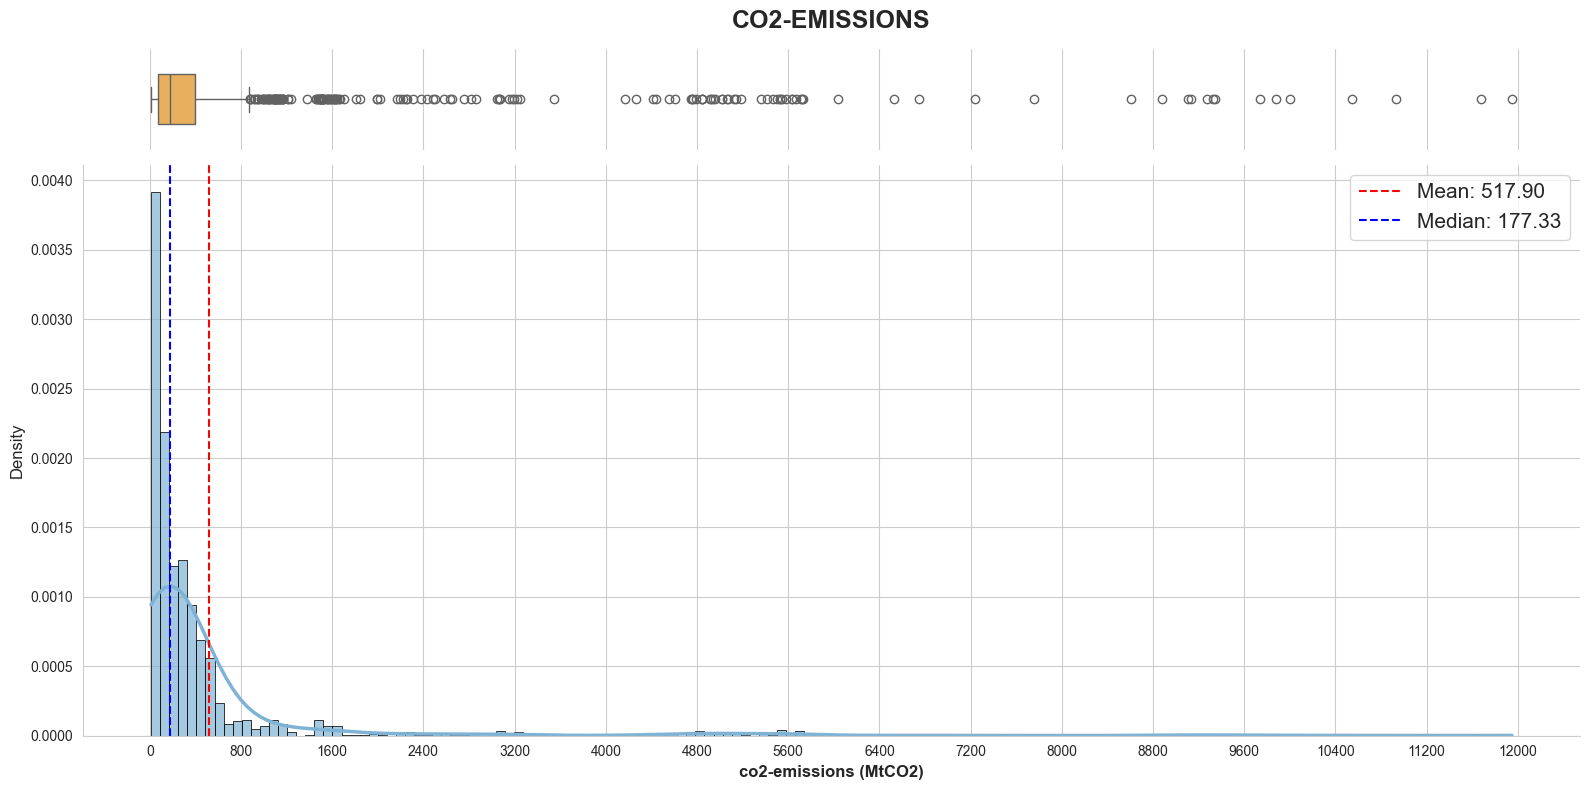

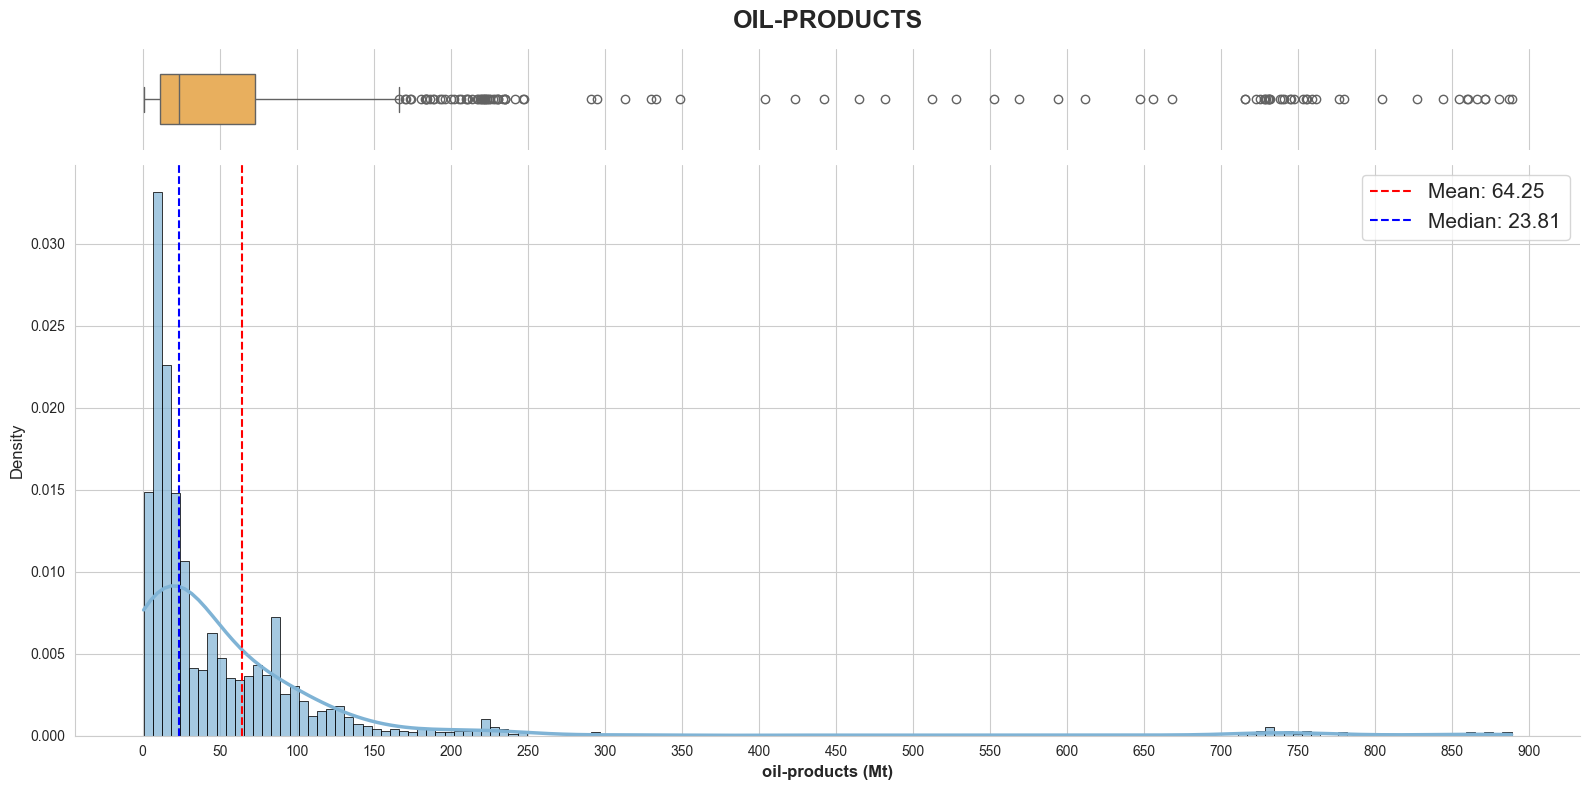

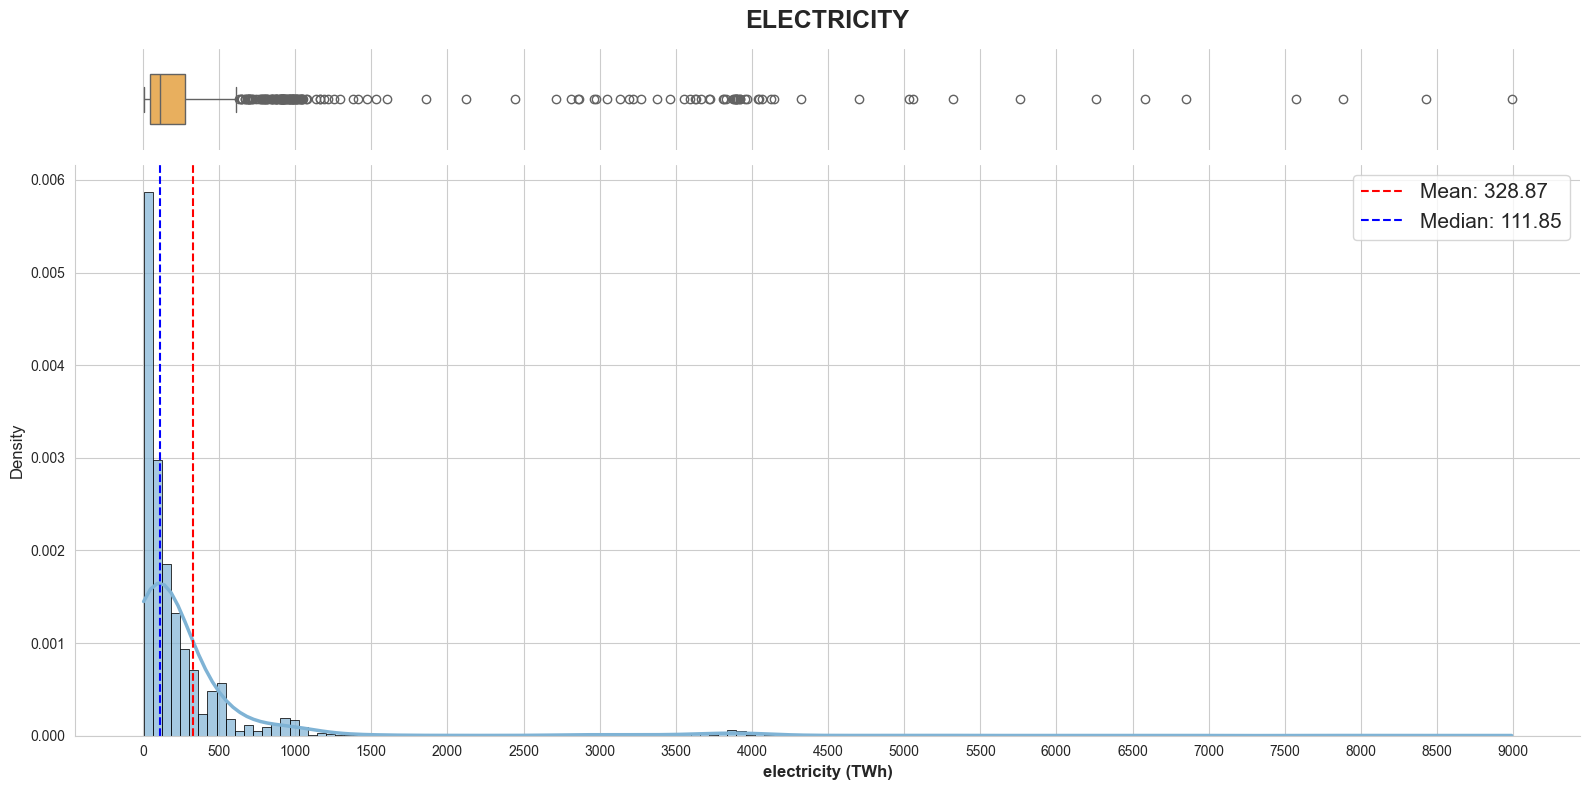

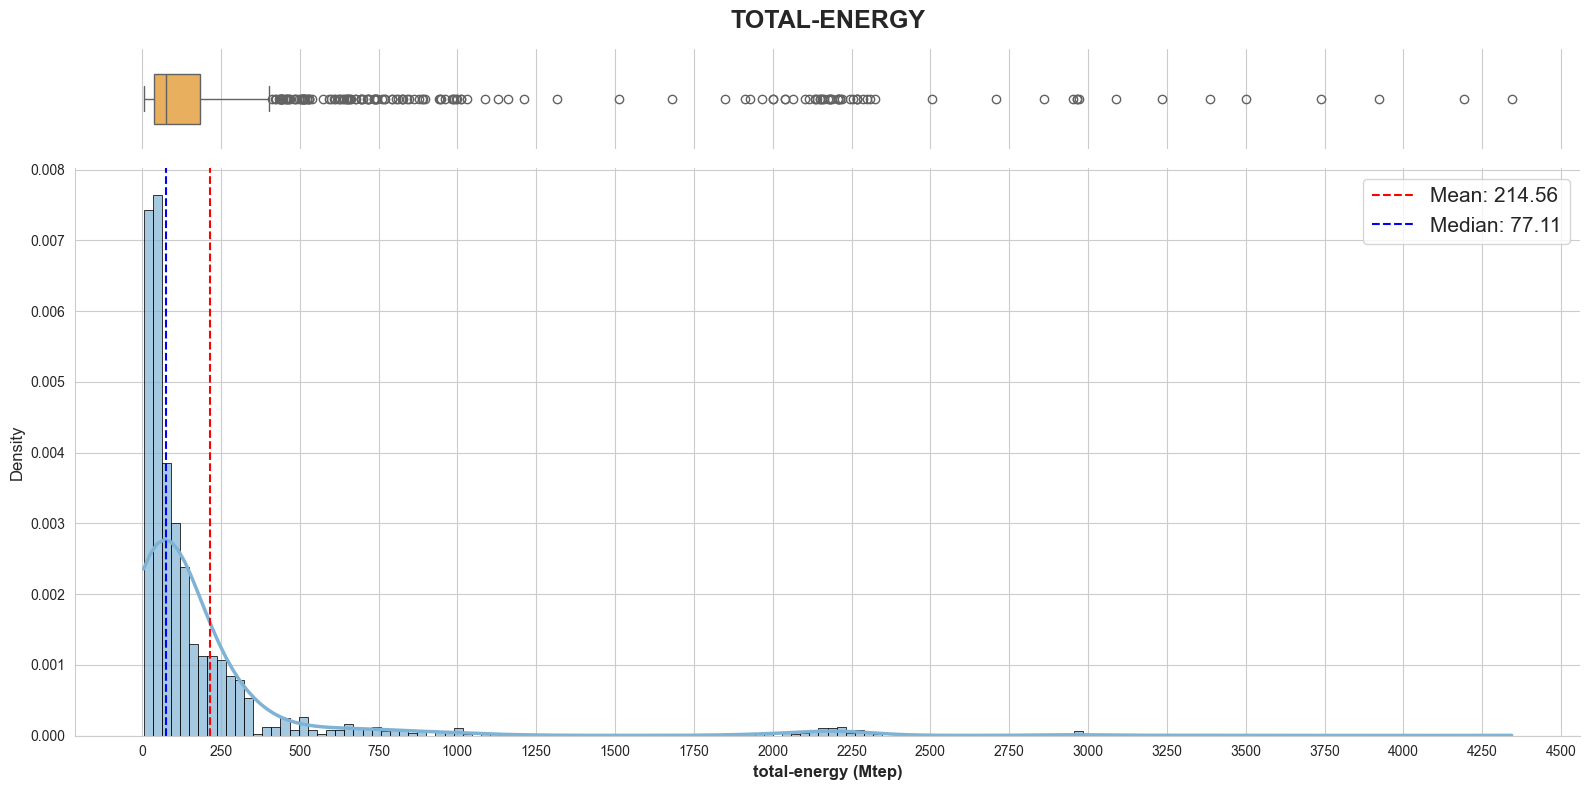

In [ ]:
unit_map = {
    'total-energy': 'Mtep', 
    'coal-lignite': 'Mt', 
    'oil-products': 'Mt', 
    'natural-gas': 'Gm3', 
    'electricity': 'TWh', 
    'renewables': '%', 
    'renewables-wind-solar': '%', 
    'co2-emissions': 'MtCO2'
}

sns.set_style("whitegrid")
cols_to_plot = ['co2-emissions', 'oil-products', 'electricity', 'total-energy']

for col_name in cols_to_plot:
    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(16, 8))
    
    sns.boxplot(data=df, x=col_name, ax=ax_box, color='#ffb347', width=0.5)
    
    ax_box.set_title(col_name.upper(), fontsize=18, pad=15, fontweight='bold')
    ax_box.set_xlabel('') 
    
    sns.histplot(data=df, x=col_name, bins=150, kde=True, stat='density', 
                 color='#7fb3d5', edgecolor='black', alpha=0.7, ax=ax_hist,
                 line_kws={'color': '#000080', 'linewidth': 2.5})
    
    mean_val = df[col_name].mean()
    median_val = df[col_name].median()
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    
    ax_hist.xaxis.set_major_locator(ticker.MaxNLocator(20))
    
    unit = unit_map.get(col_name, "") 
    ax_hist.set_xlabel(f"{col_name} ({unit})", fontsize=12, fontweight='bold')
    
    ax_hist.set_ylabel('Density', fontsize=12)
    ax_hist.legend(loc='upper right', fontsize=15)
    
    for ax in [ax_box, ax_hist]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_box.spines['left'].set_visible(False)
    ax_box.spines['bottom'].set_visible(False)
    ax_box.set_yticks([]) 

    plt.tight_layout()
    plt.show()

- Nhìn tổng thể, cả bốn đặc trưng đều có chung một hình thái phân phối là dữ liệu bị lệch phải rất mạnh, điều này khẳng định Đa số các quốc gia chỉ tiêu thụ/phát thải ở mức thấp chỉ một số ít các quốc gia phát triển có mức tiêu thụ khổng lồ
- Đỉnh cao nhất của Histogram nằm ở sát trục tung (giá trị thấp) cho thấy số lượng các quốc gia đang phát triển hoặc quốc gia nhỏ chiếm đa số trong tập dữ liệu và lượng tiêu thụ các loại năng lượng thấp hơn rất nhiều so với các nước đã phát triển
- Nhìn vào phần Boxplot, một dải dài các dấu chấm tròn kéo dài về phía bên phải. Đây là các những giá trị tiêu thụ năng lượng khổng lồ của các siêu cường kinh tế.



## 2. LÀM SẠCH VÀ CHUẨN HÓA DỮ LIỆU

## 2.1 Làm sạch dữ liệu

### a. Xử lý NaN

In [44]:
df_with_nan = df[df.isna().any(axis=1)]


print("Một số mẫu dữ liệu chứa giá trị NaN:")
display(df_with_nan)
def get_missing_columns(group):
    missing_cols = group.columns[group.isna().any()].tolist()
    return ", ".join(missing_cols)


missing_summary = df_with_nan.groupby('Country')['Year'].agg(
    Năm_Bắt_Đầu_Thiếu='min',
    Năm_Kết_Thúc_Thiếu='max',
    Số_Lượng_Năm_Thiếu='count'
)
missing_columns_info = df_with_nan.groupby('Country').apply(get_missing_columns)
missing_columns_info.name = 'Các_Loại_Năng_Lượng_Bị_Thiếu'


final_summary = missing_summary.join(missing_columns_info)


print("\nThống kê chi tiết thiếu dữ liệu theo từng quốc gia:")
display(final_summary)

Một số mẫu dữ liệu chứa giá trị NaN:


,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
735,Kuwait,1990,32.276646,NaN,14.449000,6.991713,4.728768,0.0,0.0,14.008281
736,Kuwait,1991,14.159879,NaN,8.200000,0.934218,4.046000,0.0,0.0,5.365732
737,Kuwait,1992,29.218818,NaN,13.100000,5.244336,3.814000,0.0,0.0,11.168121
738,Kuwait,1993,41.412564,NaN,13.800000,9.779819,5.196854,0.0,0.0,18.503931
739,Kuwait,1994,46.063431,NaN,18.200000,10.157003,6.301782,0.0,0.0,20.563000
...,...,...,...,...,...,...,...,...,...,...
1115,Qatar,2020,83.716713,NaN,43.089429,54.983413,8.235634,NaN,NaN,47.454177
1116,Qatar,2021,85.418330,NaN,45.404091,56.484472,8.506351,NaN,NaN,49.118396
1117,Qatar,2022,90.490540,NaN,48.199426,55.262505,9.304758,NaN,NaN,50.551556
1118,Qatar,2023,94.936942,NaN,52.593095,57.694707,9.970719,NaN,NaN,53.221001



Thống kê chi tiết thiếu dữ liệu theo từng quốc gia:


,Năm_Bắt_Đầu_Thiếu,Năm_Kết_Thúc_Thiếu,Số_Lượng_Năm_Thiếu,Các_Loại_Năng_Lượng_Bị_Thiếu
Country,,,,
Kuwait,1990,2024,35,coal-lignite
Qatar,1990,2024,35,"coal-lignite, renewables, renewables-wind-solar"


- Nhận xét
    + Nhóm nghiên cứu thấy giá trị NaN này thuộc hoàn toàn về 2 nước Kuwait và Qatar từ 1990 - 2024 (do nhà cung cấp không thu thập được dữ liệu từ 2 nước này)
    + Từ đó, nhóm kết luận rằng rằng các giá trị dữ liệu thiếu trong trường hợp này không phải do lỗi thu thập dữ liệu, mà xuất phát từ bản chất thực tế của hệ thống năng lượng tại các quốc gia này. Vì mức tiêu thụ các loại năng lượng này gần như bằng 0, các giá trị NaN có thể được thay thế bằng 0 trong quá trình tiền xử lý dữ liệu để phản ánh đúng thực tế tiêu thụ năng lượng.

### Thay thế các giá trị NaN 

In [45]:

dulieu_xuly_nan = df.copy()
cols_to_fill_zero = ['coal-lignite', 'renewables', 'renewables-wind-solar']


# Thay NaN bằng 0
dulieu_xuly_nan[cols_to_fill_zero] = dulieu_xuly_nan[cols_to_fill_zero].fillna(0)

print("Số lượng NaN của các cột sau khi xử lý:")
print(dulieu_xuly_nan[cols_to_fill_zero].isna().sum())

Số lượng NaN của các cột sau khi xử lý:
coal-lignite             0
renewables               0
renewables-wind-solar    0
dtype: int64


### Phân phối các biến sau khi xử lý NaN

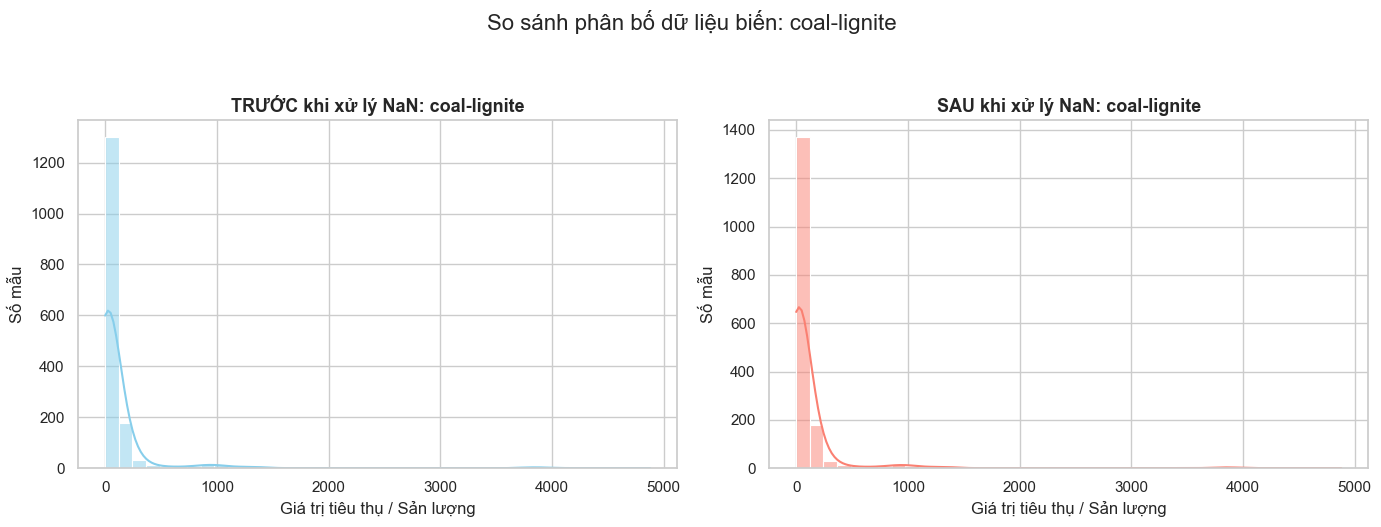

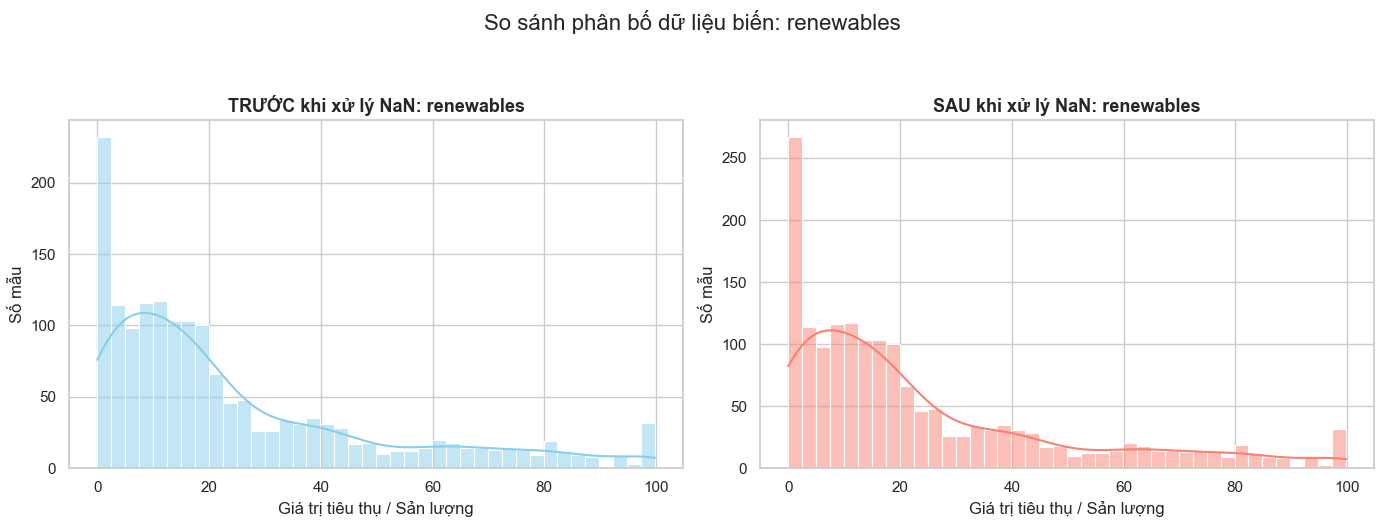

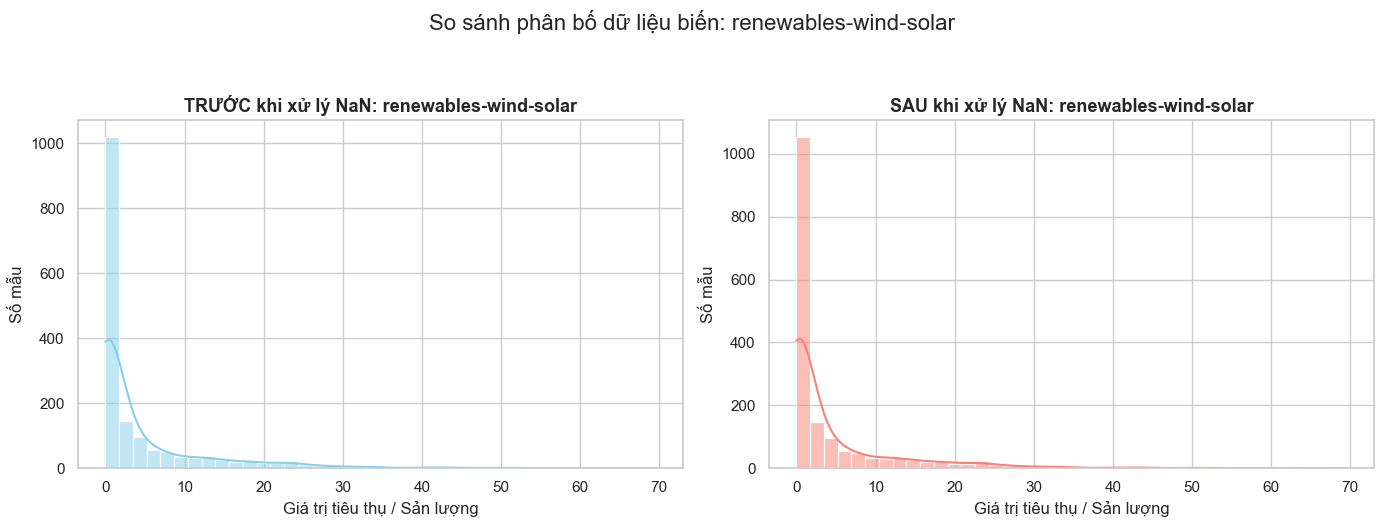

In [51]:
energy_cols = ['coal-lignite' ,'renewables','renewables-wind-solar']


sns.set_theme(style="whitegrid")


for col in energy_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[col].dropna(), bins=40, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'TRƯỚC khi xử lý NaN: {col}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Giá trị tiêu thụ / Sản lượng')
    axes[0].set_ylabel('Số mẫu')


    sns.histplot(dulieu_xuly_nan[col], bins=40, kde=True, color='salmon', ax=axes[1])
    axes[1].set_title(f'SAU khi xử lý NaN: {col}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Giá trị tiêu thụ / Sản lượng')
    axes[1].set_ylabel('Số mẫu')
   
    plt.suptitle(f'So sánh phân bố dữ liệu biến: {col}', fontsize=16, y=1.05)
   
    plt.tight_layout()
    plt.show()

- Nhận xét
    + Thay thế dữ liệu bị thiếu bằng 0 làm tăng số giá trị 0 ở một số biến (coal-lignite, renewables).
    + Phân bố dữ liệu gần như giữ nguyên, các biến vẫn lệch phải.
    + Thay NaN bằng 0 không làm thay đổi đáng kể phân bố dữ liệu và phù hợp với thực tế rằng một số quốc gia không sử dụng hoặc không sản xuất một số loại năng lượng

### b. Xử lý Outlier

- Xử lý outlier được nhóm nghiên cứu lựa chọn phương pháp Capping dựa trên IQR, vì trong tập dữ liệu, một số biến (C02 emissions, total-energy, oil-products,..) có sự chênh lệch rất lớn giữa các quốc gia nên có nhiều giá trị outlier lớn, làm cho dữ liệu lệch phải nặng
- Nếu sử dụng Winsorization thông thường với 1.5IQR thì nhiều giá trị tiêu thụ lớn nhưng hợp lý sẽ bị cắt đi, làm mất thông tin quan trọng về lượng tiêu thụ năng lượng của một số nước lớn.
- Riêng biến Renewables nếu Capping với 3IQR thì điểm cắt sẽ khá xa, vượt ra khỏi các giá trị outlier lớn, và sẽ không cắt được điểm nào vì vậy đối với biến Renewable sẽ áp dụng xử lý Outlier theo phương pháp Winsorization

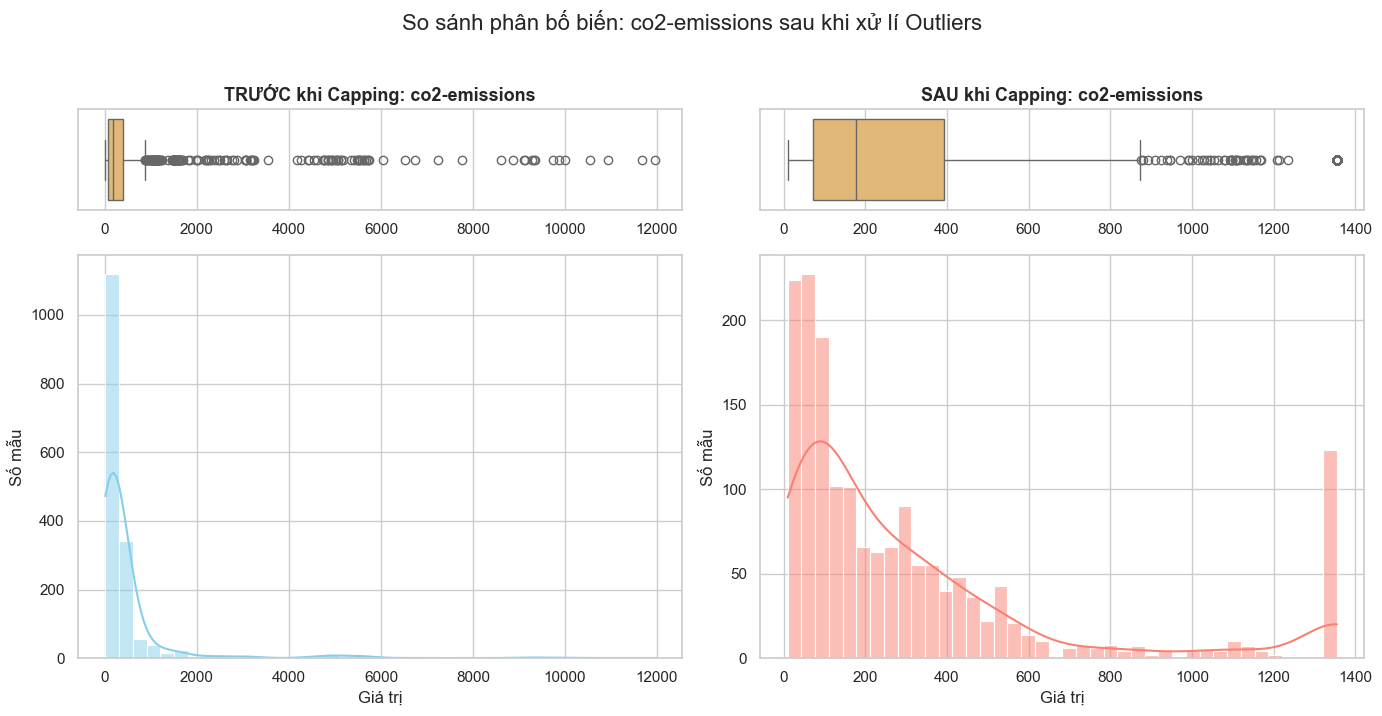

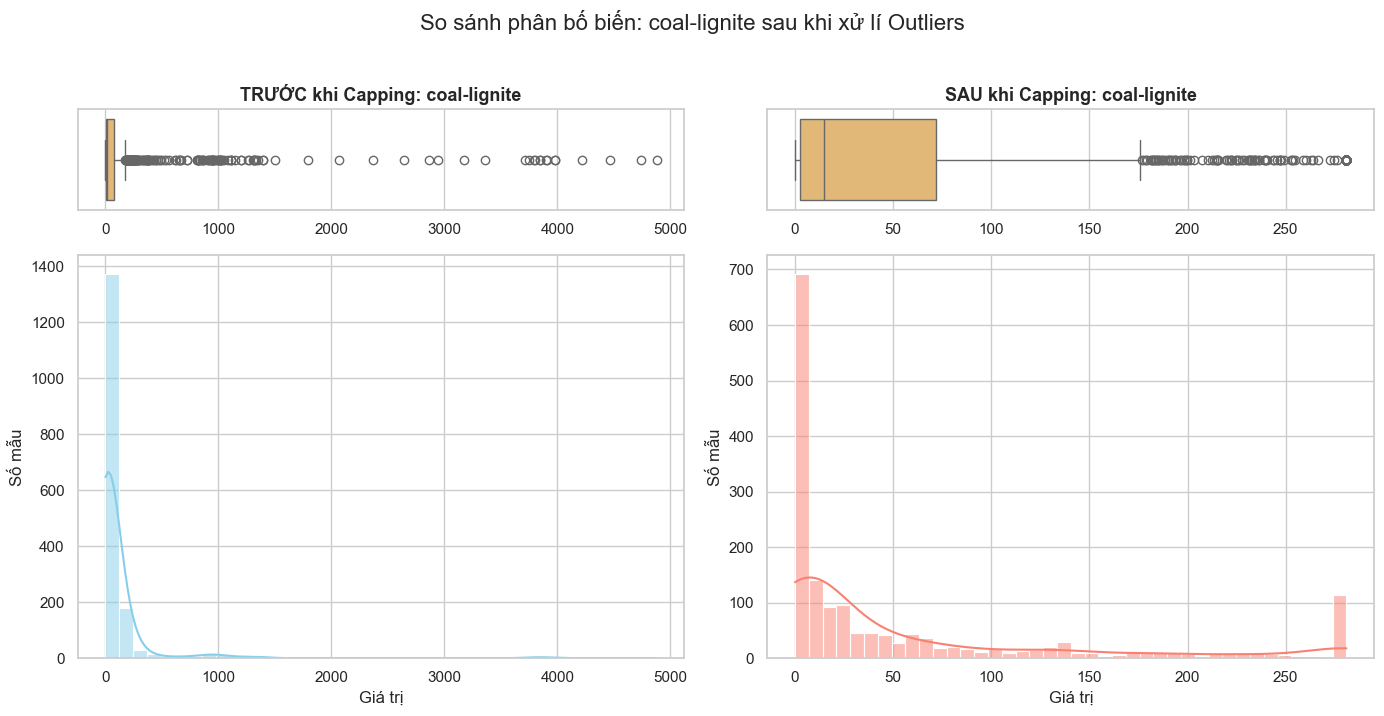

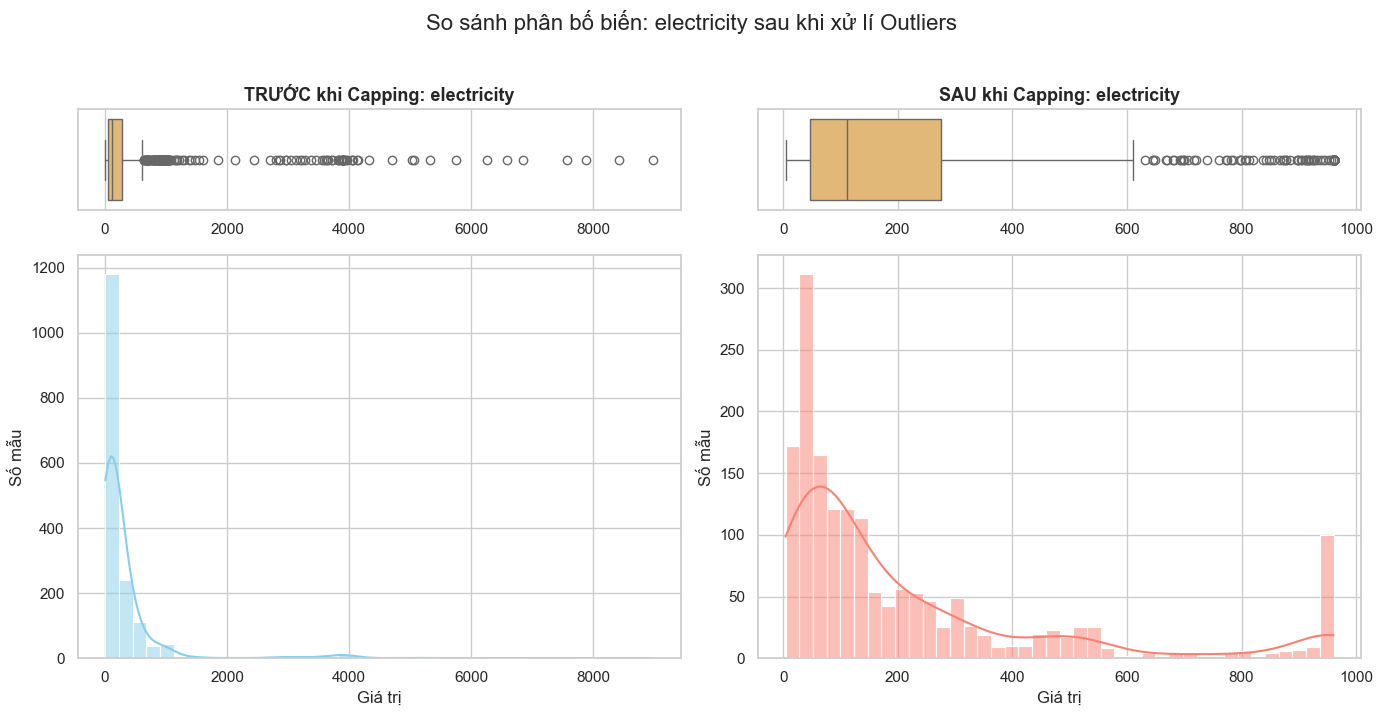

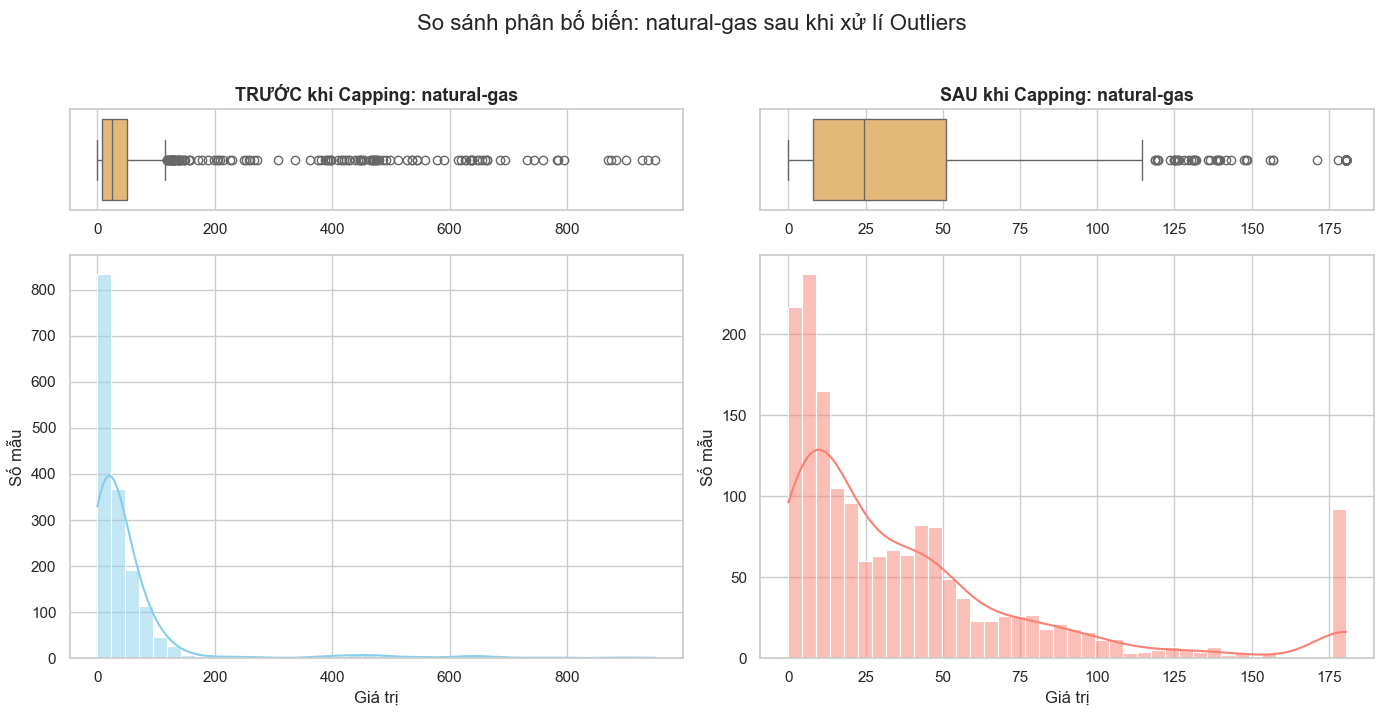

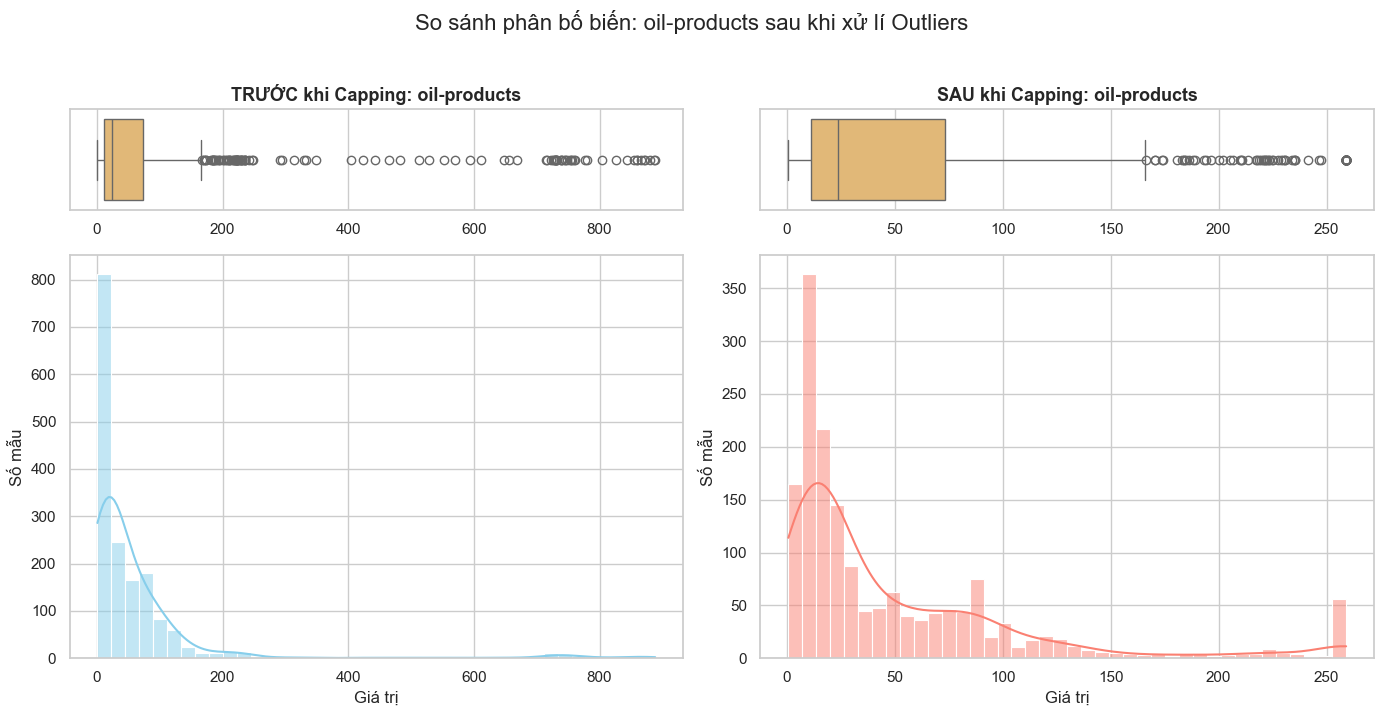

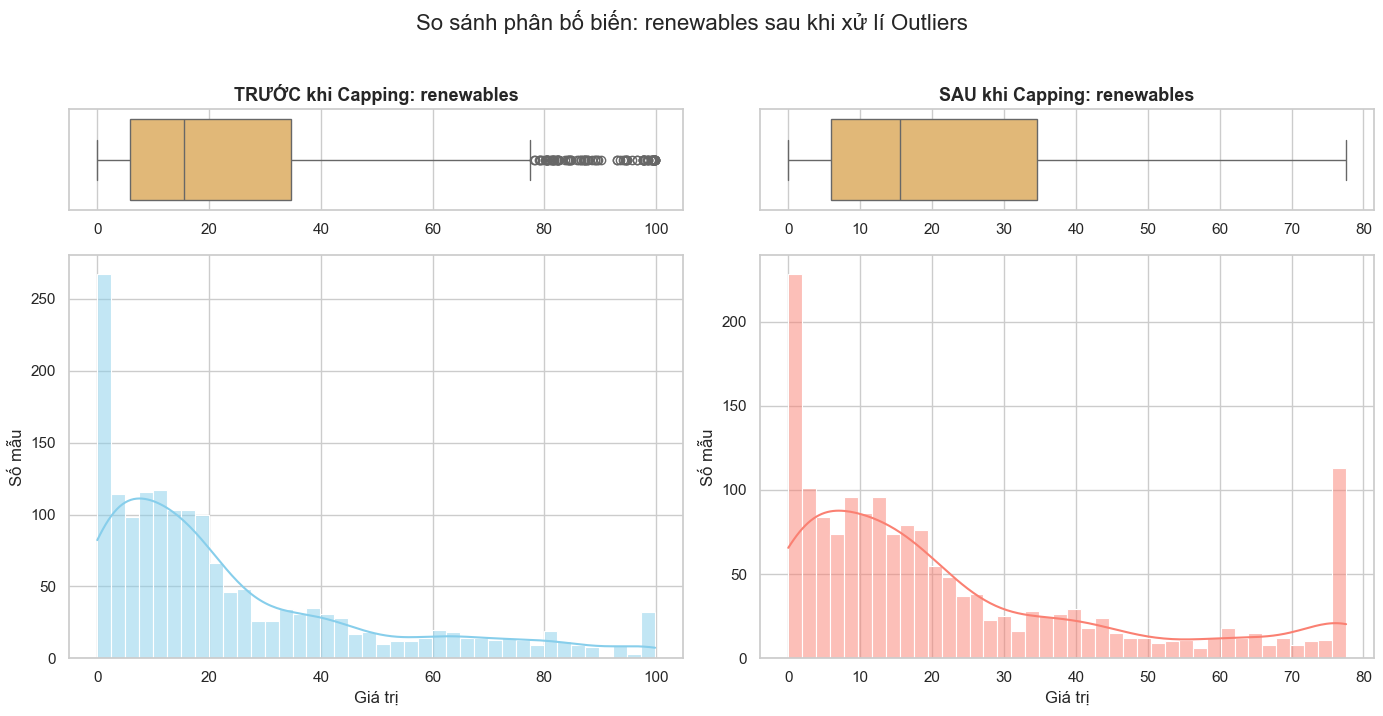

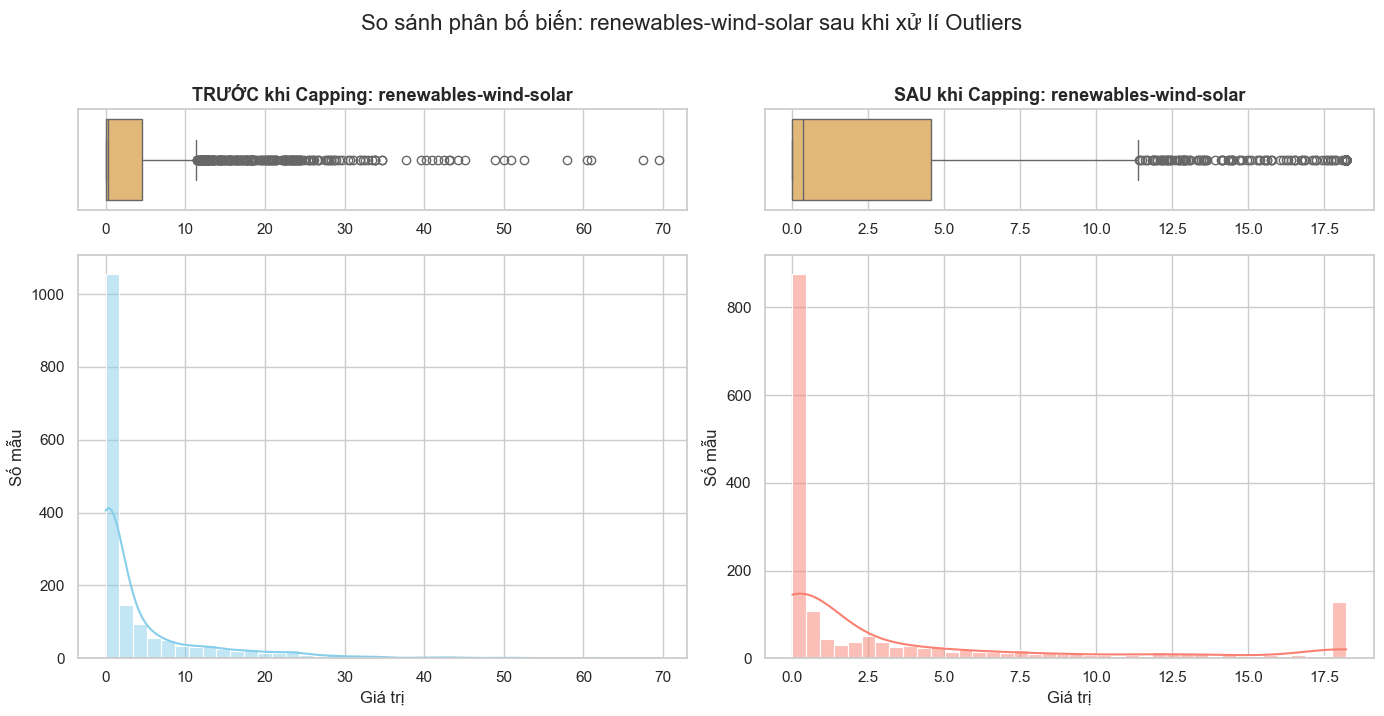

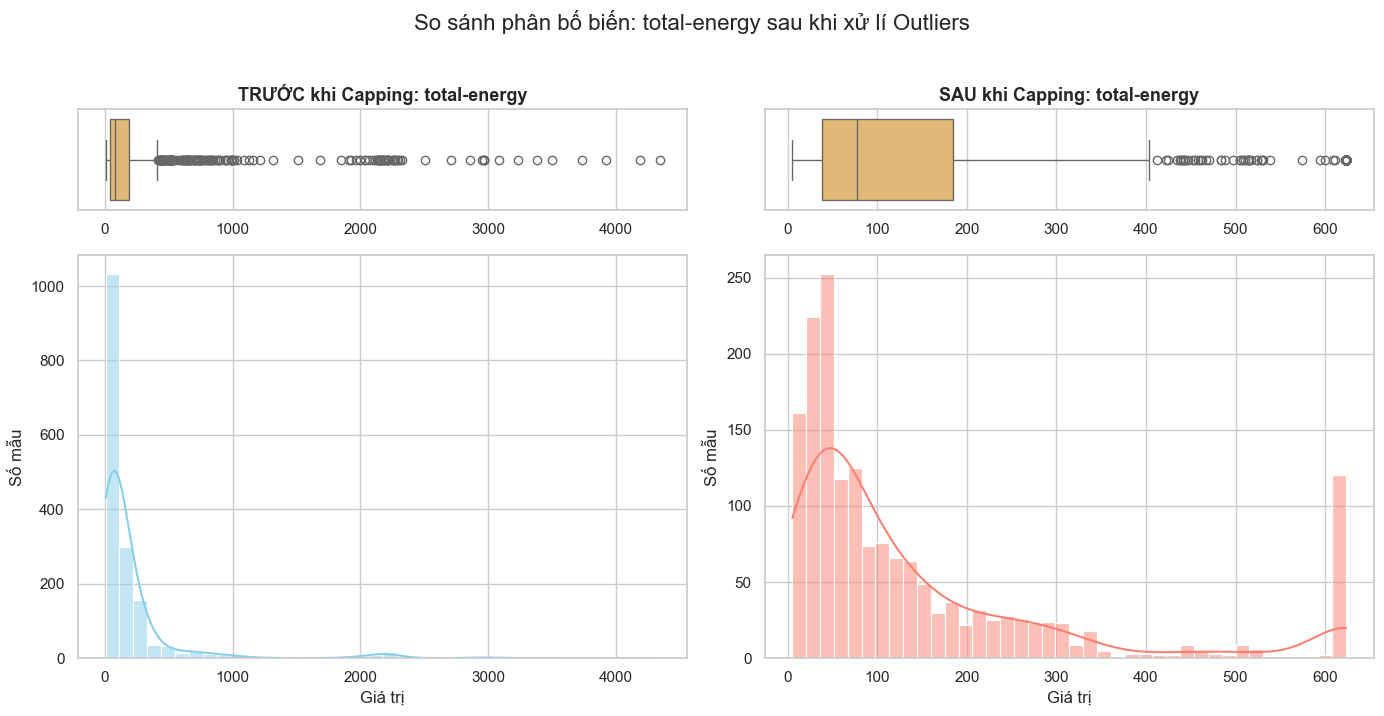

In [52]:
dulieu_truocxuly_outlier = dulieu_xuly_nan.copy()
dulieu_xuly_outlier = dulieu_truocxuly_outlier.copy()


energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity',
    'natural-gas', 'oil-products', 'renewables',
    'renewables-wind-solar', 'total-energy'
]


for col in energy_cols:
    Q1 = dulieu_xuly_outlier[col].quantile(0.25)
    Q3 = dulieu_xuly_outlier[col].quantile(0.75)
    IQR = Q3 - Q1


    if col == 'renewables':
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    else:
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR


    dulieu_xuly_outlier[col] = dulieu_xuly_outlier[col].clip(lower=lower_bound, upper=upper_bound)

sns.set_theme(style="whitegrid")


for col in energy_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'height_ratios': [0.2, 0.8]})


    # BEFORE
    sns.boxplot(x=dulieu_truocxuly_outlier[col], ax=axes[0, 0], color='#f2bc66')
    axes[0, 0].set_title(f'TRƯỚC khi Capping: {col}', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('')


    sns.histplot(dulieu_truocxuly_outlier[col], bins=40, kde=True, color='skyblue', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Giá trị')
    axes[1, 0].set_ylabel('Số mẫu')


    # AFTER
    sns.boxplot(x=dulieu_xuly_outlier[col], ax=axes[0, 1], color='#f2bc66')
    axes[0, 1].set_title(f'SAU khi Capping: {col}', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('')


    sns.histplot(dulieu_xuly_outlier[col], bins=40, kde=True, color='salmon', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Giá trị')
    axes[1, 1].set_ylabel('Số mẫu')


    plt.suptitle(f'So sánh phân bố biến: {col} sau khi xử lí Outliers', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

- Nhận xét sau khi xử lý outliers
    + Sau khi xử lý, phần lớn các biến vẫn giữ phân bố lệch phải, phản ánh sự khác biệt lớn giữa các quốc gia về tiêu thụ năng lượng và phát thải. Việc xử lý outliers giúp giảm ảnh hưởng của các giá trị quá lớn, khiến dữ liệu ổn định và dễ phân tích hơn.
    + Khi sử dụng ngưỡng 3IQR thì chỉ những giá trị nằm rất xa mới bị giới hạn. Các điểm nằm trong khoảng 1.5IQR đến 3IQR vẫn là nhưng giá trị ngoại lai , từ đó sử dụng phương pháp chuẩn hóa RobustScaler, vì phương pháp này dựa trên median và IQR nên ít bị ảnh hưởng bởi các giá trị ngoại lại còn lại.

## 2.2 Chuẩn hóa dữ liệu

- Sử dụng chuẩn hóa mạnh (RobustScaler) vì dữ liệu năng lượng có outlier (giá trị lớn/ nhỏ) giữa các quốc gia
- RobustScaler chuẩn hóa dữ liệu bằng median và IQR thay vì mean và độ lệch chuẩn, nên ít bị ảnh hưởng bởi outlier và giúp dữ liệu ổn định hơn cho mô hình học máy.

In [53]:
energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]
scaler = RobustScaler()
bien_da_chuanhoa = dulieu_xuly_outlier.copy()
bien_da_chuanhoa[energy_cols] = scaler.fit_transform(bien_da_chuanhoa[energy_cols])
print("Đã chuẩn hóa xong 8 cột bằng RobustScaler")

Đã chuẩn hóa xong 8 cột bằng RobustScaler


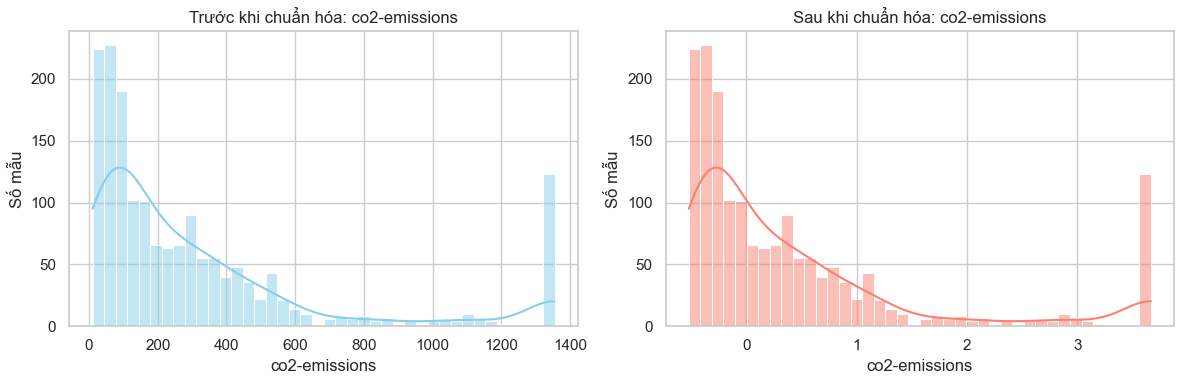

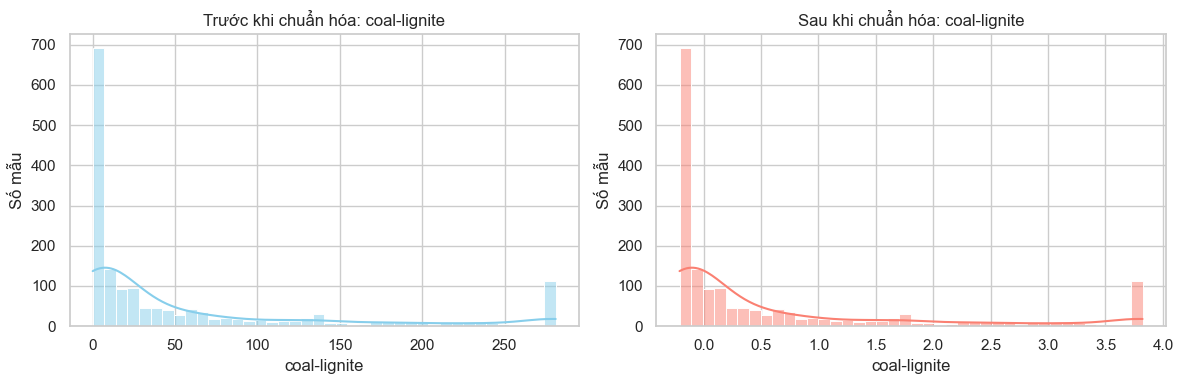

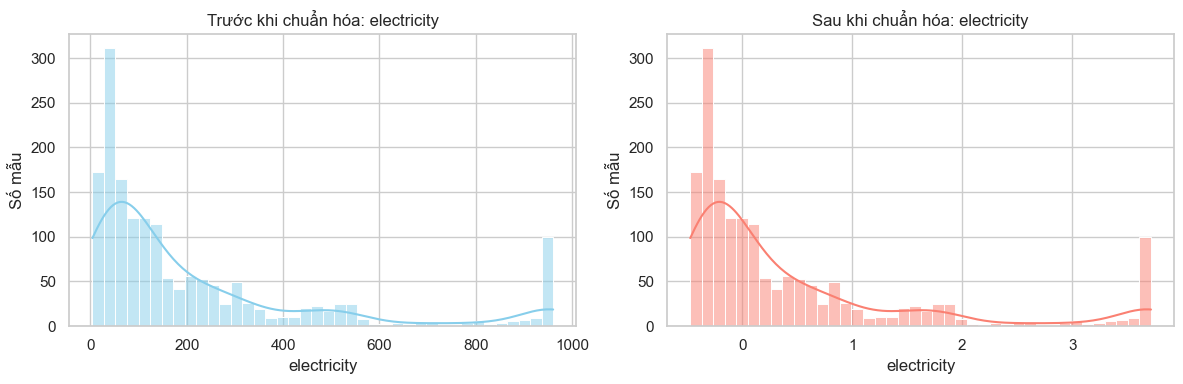

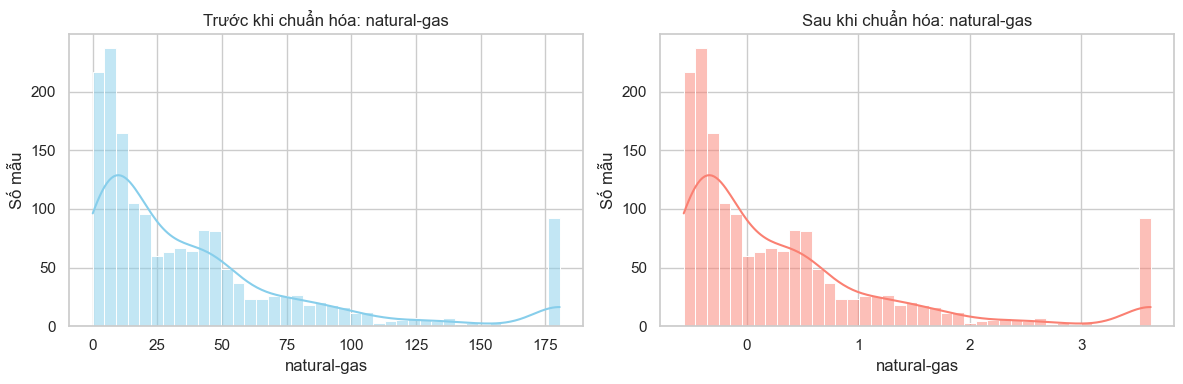

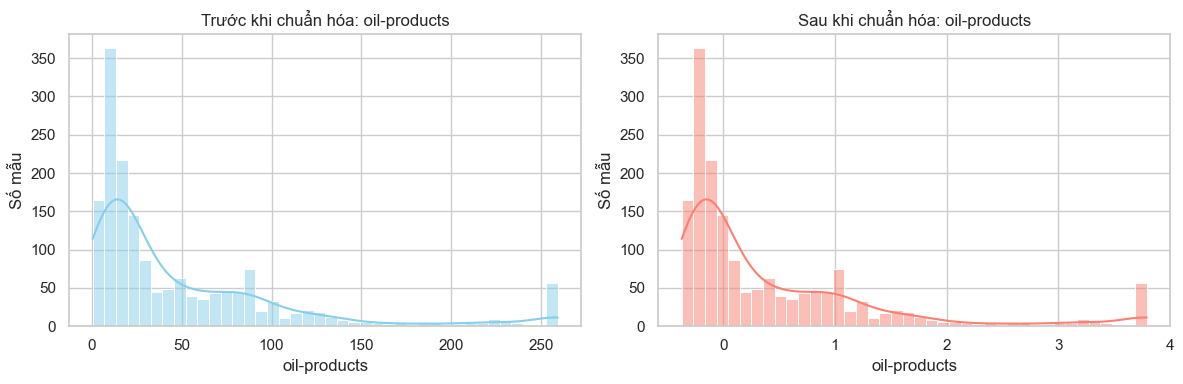

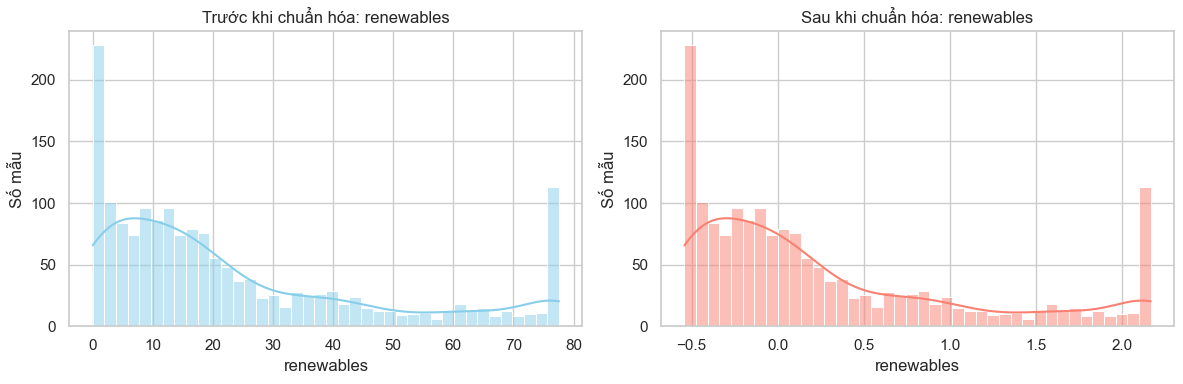

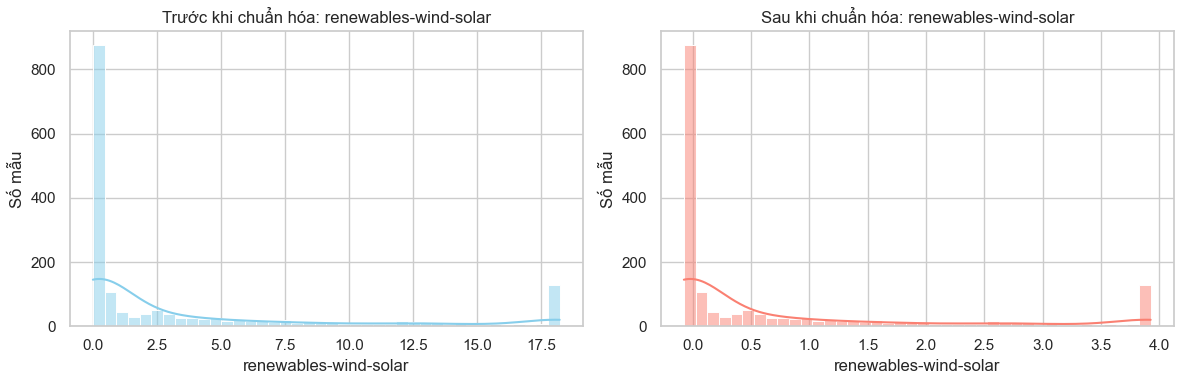

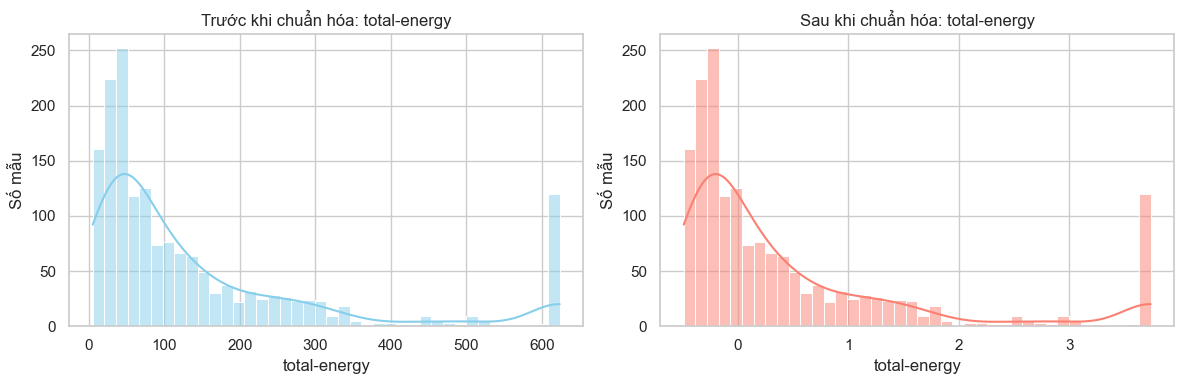

In [55]:
energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]

sns.set_theme(style="whitegrid")

for col in energy_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(dulieu_xuly_outlier[col], bins=40, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Trước khi chuẩn hóa: {col}')
    axes[0].set_ylabel('Số mẫu')
    
    sns.histplot(bien_da_chuanhoa[col], bins=40, kde=True, color='salmon', ax=axes[1])
    axes[1].set_title(f'Sau khi chuẩn hóa: {col}')
    axes[1].set_ylabel('Số mẫu')
    
    plt.tight_layout()
    plt.show()

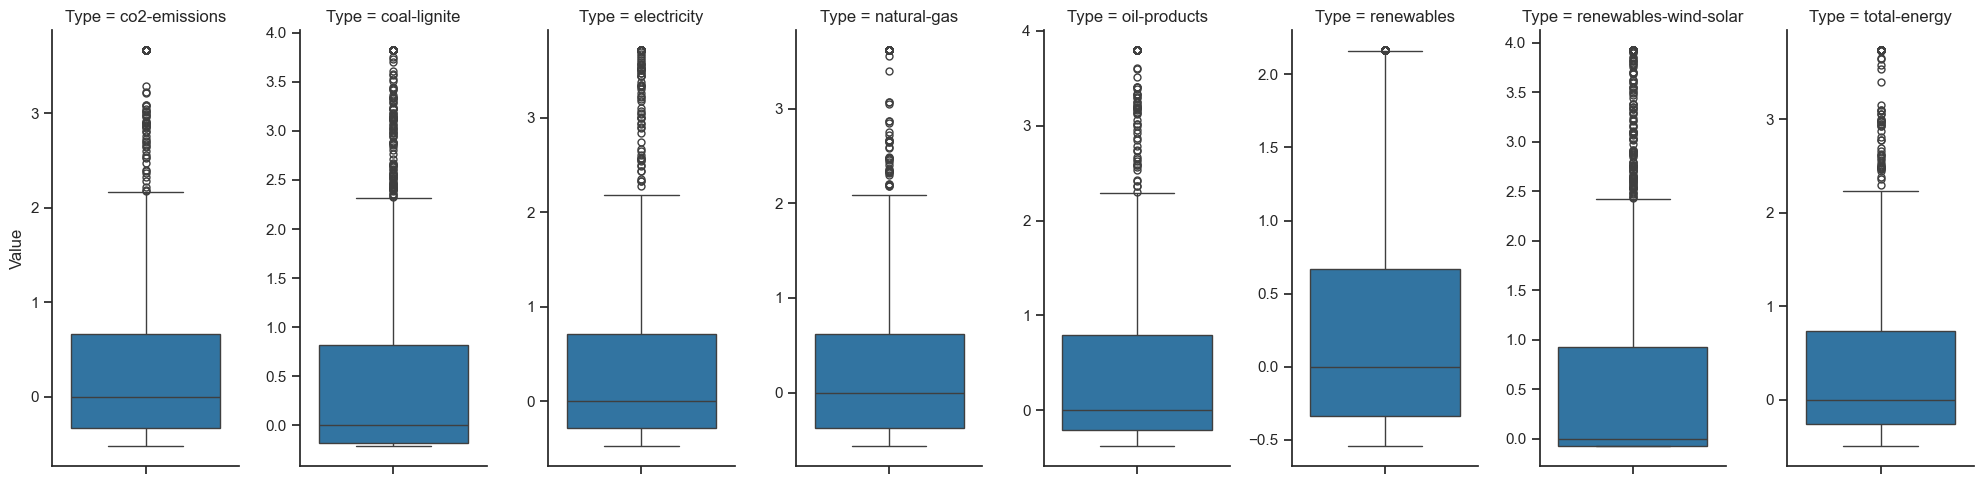

In [ ]:
energy_cols = [
    'co2-emissions', 'coal-lignite', 'electricity', 
    'natural-gas', 'oil-products', 'renewables', 
    'renewables-wind-solar', 'total-energy'
]

du_lieu_dang_dai = bien_da_chuanhoa.melt(value_vars=energy_cols, var_name='Type', value_name='Value')

sns.set_theme(style="ticks") 

g = sns.catplot(
    data=du_lieu_dang_dai,
    y='Value',
    col='Type',    
    kind='box',
    sharex=False,
    sharey=False,
    height=5,
    aspect=0.5,
    legend=False,
    color='#1f77b4'
)

plt.show()

- Nhận xét sau khi chuẩn hóa bằng RobustScaler
    + Sau khi chuẩn hóa, các biến năng lượng vẫn lệch phải, cho thấy sự chênh lệch tiêu thụ giữa các quốc gia (đa số thấp, một số rất cao).
    + Boxplot cho thấy vẫn còn một số giá trị nằm ngoài khoảng IQR, phản ánh sự chênh lệch tiêu thụ năng lượng giữa các quốc gia.Tuy nhiên, sau khi chuẩn hóa, dữ liệu đã được đưa về cùng thang đo quanh trung vị, giúp giảm ảnh hưởng của các giá trị quá lớn.

### Sau khi làm sạch và chuẩn hóa , lưu dữ liệu vào file clean_data.csv

In [59]:
bien_da_chuanhoa.to_csv("clean_data.csv", index= False)

### Lấy ra 5 dòng đầu tiên xem 

In [60]:
df_clean = pd.read_csv("clean_data.csv")
df_clean.head()

,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
0,Algeria,1990,-0.396270,-0.194669,-0.434796,-0.225988,-0.253893,-0.512282,-0.074254,-0.382598
1,Algeria,1991,-0.386607,-0.194999,-0.433425,-0.198129,-0.247252,-0.482594,-0.074254,-0.368928
2,Algeria,1992,-0.378243,-0.195960,-0.428634,-0.188177,-0.237510,-0.503562,-0.074254,-0.362055
3,Algeria,1993,-0.369895,-0.198774,-0.428884,-0.125719,-0.248339,-0.478096,-0.074254,-0.349363
4,Algeria,1994,-0.372795,-0.197295,-0.427369,-0.121270,-0.259606,-0.512409,-0.074254,-0.342533


## 3. MÃ HÓA DỮ LIỆU CHO BIẾN DANH MỤC

In [65]:
dulieu_mahoa = bien_da_chuanhoa.copy()
le = LabelEncoder()
dulieu_mahoa['Country'] = le.fit_transform(dulieu_mahoa['Country'])

print(f"✅ Đã mã hóa xong {len(le.classes_)} quốc gia'!")

mapping_df = pd.DataFrame({
    'Mã số': range(len(le.classes_)),
    'Tên quốc gia': le.classes_
})

print("\n--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA (10 dòng đầu)")
print(mapping_df.head(10).to_string(index=False))



✅ Đã mã hóa xong 48 quốc gia'!

--- BẢNG ÁNH XẠ MÃ SỐ VÀ TÊN QUỐC GIA (10 dòng đầu)
 Mã số Tên quốc gia
     0      Algeria
     1    Argentina
     2    Australia
     3   Azerbaijan
     4      Belgium
     5       Brazil
     6       Canada
     7        Chile
     8        China
     9     Colombia


### Lưu vào file clean_data.csv và hiển thị 5 dòng đầu tiên

In [66]:
dulieu_mahoa.to_csv("clean_data.csv", index=False)
print("Lưu thành công dũ liệu vào clean_data.csv!")
dulieu_mahoa.head()

Lưu thành công dũ liệu vào clean_data.csv!


,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products,renewables,renewables-wind-solar,total-energy
0,0,1990,-0.396270,-0.194669,-0.434796,-0.225988,-0.253893,-0.512282,-0.074254,-0.382598
1,0,1991,-0.386607,-0.194999,-0.433425,-0.198129,-0.247252,-0.482594,-0.074254,-0.368928
2,0,1992,-0.378243,-0.195960,-0.428634,-0.188177,-0.237510,-0.503562,-0.074254,-0.362055
3,0,1993,-0.369895,-0.198774,-0.428884,-0.125719,-0.248339,-0.478096,-0.074254,-0.349363
4,0,1994,-0.372795,-0.197295,-0.427369,-0.121270,-0.259606,-0.512409,-0.074254,-0.342533


## 4. XÂY DỰNG VÀ LỰA CHỌN ĐẶC TRƯNG

### Sử dụng mô hinh Simple Linear Regression (SLR): Hồi quy tuyến tính đơn biến để xem biến nào có tác động mạnh nhất tới biến mục tiêu Y (lượng phát thải CO2).

In [67]:
import pandas as pd
import statsmodels.api as sm

df = dulieu_mahoa.copy()
results_list = []

Y = df['co2-emissions']
features_to_test = [
    'coal-lignite', 'natural-gas', 'oil-products', 
    'electricity', 'renewables', 'renewables-wind-solar', 'total-energy'
]

for col in features_to_test:
    X_single = df[col] 
    X_single_with_const = sm.add_constant(X_single)

    model = sm.OLS(Y, X_single_with_const).fit()

    results_list.append({
        'Đặc trưng': col.upper(),
        'R-squared': round(model.rsquared, 4),
        'P-value': f"{model.pvalues[col]:.4e}",
        'Ý nghĩa': "Có" if model.pvalues[col] < 0.05 else "Không"
    })

df_results = pd.DataFrame(results_list)
print("📊 BẢNG TỔNG HỢP MỐI QUAN HỆ CỦA CÁC ĐẶC TRƯNG VỚI CO2")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

📊 BẢNG TỔNG HỢP MỐI QUAN HỆ CỦA CÁC ĐẶC TRƯNG VỚI CO2
            Đặc trưng  R-squared    P-value Ý nghĩa
         COAL-LIGNITE     0.7716 0.0000e+00      Có
          NATURAL-GAS     0.6011 0.0000e+00      Có
         OIL-PRODUCTS     0.8579 0.0000e+00      Có
          ELECTRICITY     0.8990 0.0000e+00      Có
           RENEWABLES     0.0321 1.4214e-13      Có
RENEWABLES-WIND-SOLAR     0.0004 4.2031e-01   Không
         TOTAL-ENERGY     0.9732 0.0000e+00      Có


- Nhận xét về mô hình hồi quy tuyến tính đơn biến:
    + Các đặc trưng total_energy, coal, gas, oil có điểm R-square đều rất gần 1 tức là điểm dữ liệu thức tế nó đang bám sát với đường thẳng dự đoán của mô hình. Đồng thời điểm P-value đều nhỏ hơn 0.05, điều này có nghĩa là xác suất X và Y liên quan tới nhau do ngẫu nhiên là nhỏ hơn 5%
    + Còn với renewable và renewable-wind-solar thì R-square nhỏ hơn 1 rất nhiều, P-value thì lớn hơn 0.05%. Cho thấy X và Y không có sự liên quan Vậy các điểm ta nên loại bỏ là renewable và renewable-wind-solar
    + Tuy nhiên, qua mô hình đơn biến thì chúng ta chỉ mới nhận thầy rằng các biến đặc trưng nào có khả năng liên quan tới Y. Ta sẽ sử dụng thêm mô hình Random Forest Feature Importance để đánh giá độ quan trọng của từng biến

#### Dùng Random forest với 7 biến: coal-lignite, natural-gas, oil-products, electricity, renewables, renewables-wind-solar, total-energy

BẢNG ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG BẰNG RANDOM FOREST 
------------------------------------------------------------
            Đặc trưng  Độ quan trọng (%)
         total-energy             97.93%
         coal-lignite              0.93%
          natural-gas              0.60%
         oil-products              0.25%
           renewables              0.12%
          electricity              0.11%
renewables-wind-solar              0.07%


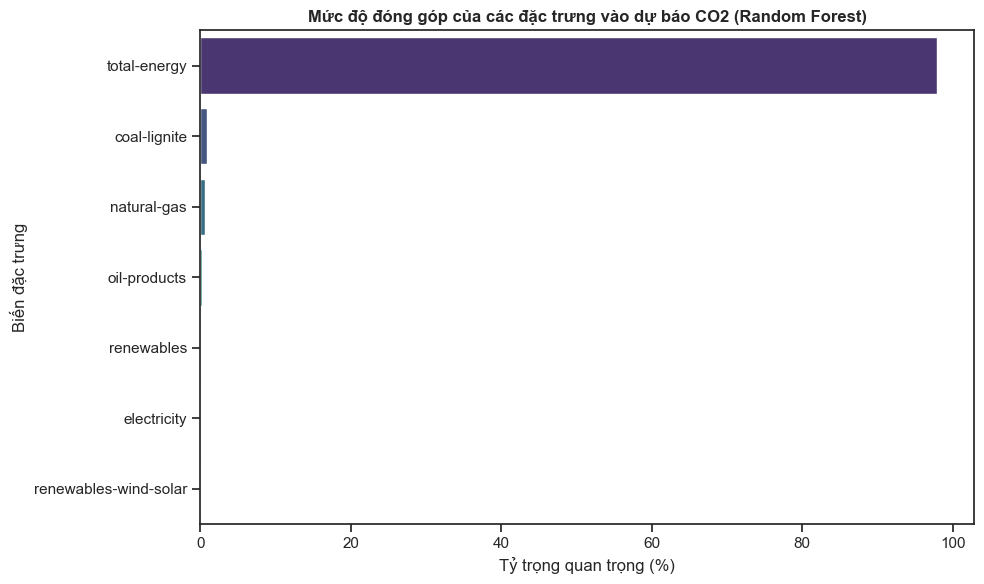

In [69]:
from sklearn.ensemble import RandomForestRegressor

features = ['coal-lignite', 'natural-gas', 'oil-products', 
            'electricity', 'renewables', 'renewables-wind-solar', 'total-energy']
X = df[features]
Y = df['co2-emissions']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, Y)

importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Đặc trưng': features,
    'Độ quan trọng (%)': importances * 100
}).sort_values(by='Độ quan trọng (%)', ascending=False)

print("BẢNG ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG BẰNG RANDOM FOREST ")
print("-" * 60)
print(feature_imp_df.to_string(index=False, float_format="%.2f%%"))

plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng (%)', y='Đặc trưng', data=feature_imp_df, palette='viridis', hue='Đặc trưng',  legend=False)
plt.title('Mức độ đóng góp của các đặc trưng vào dự báo CO2 (Random Forest)', fontweight='bold')
plt.xlabel('Tỷ trọng quan trọng (%)')
plt.ylabel('Biến đặc trưng')
plt.tight_layout()
plt.show()

- Nhận xét:
    + Khi dùng Random Forest cho 7 biến đặc trưng (có cả total) thì nó sẽ đưa ra cho chúng ta kết quả mức quan trọng total chiếm tới 97.92%, và các năng lượng khác mức độ quan trọng cực kỳ thấp. Nguyên nhân chính là do total_energy là tổng các năng lượng lại, nên nó có tương quan gần như tuyệt đối với biến mục tiêu Y. Nên khi chúng ta sử dụng Random Forest, ngay tại nút gốc chúng ta sử dụng total_energy là đã giải quyết hầu như bài toán mà bỏ qua các biến đặc trưng khác.
    + Tuy nhiên trong thực tế, lượng CO2 nó sẽ được dự đoán chính xác hơn dựa vào các năng lượng đặc trưng như coal, oil, gas, electricity. Vì mỗi năng lượng sẽ sinh ra 1 lượng CO2 khác nhau. Nó sẽ chính xác hơn việc chỉ dựa vào mỗi total để dự đoán

#### Dùng Random Forest với 6 biến coal-lignite, natural-gas, oil-products, electricity, renewables, renewables-wind-solar, không có biến Total-energy

BẢNG ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG BẰNG RANDOM FOREST 
------------------------------------------------------------
            Đặc trưng  Độ quan trọng (%)
         oil-products             62.37%
          electricity             30.68%
         coal-lignite              5.42%
          natural-gas              1.08%
           renewables              0.25%
renewables-wind-solar              0.20%


C:\Users\HP\AppData\Local\Temp\ipykernel_9840\1431525025.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng (%)', y='Đặc trưng', data=feature_imp_df, palette='viridis')


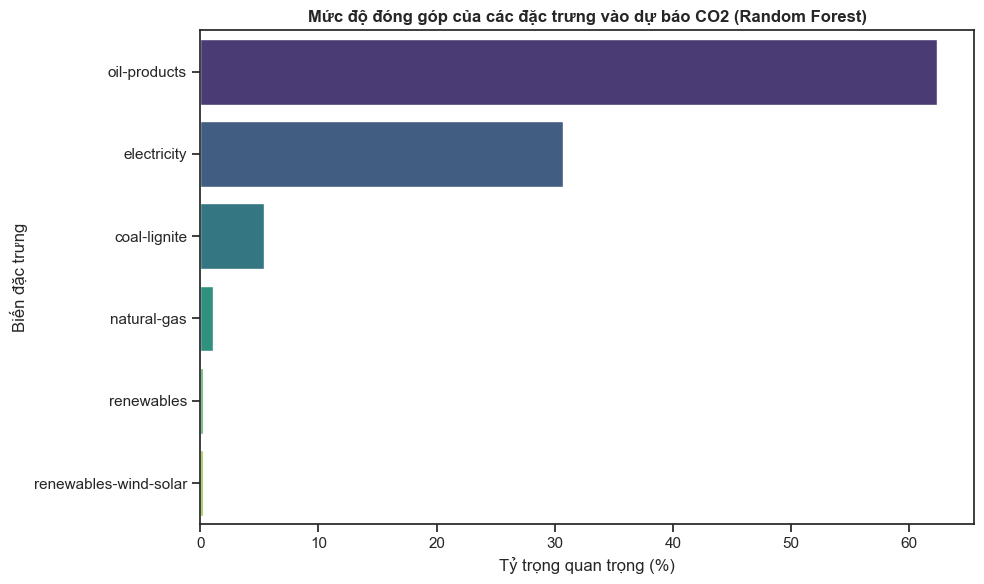

In [70]:

features = ['coal-lignite', 'natural-gas', 'oil-products', 
            'electricity', 'renewables', 'renewables-wind-solar']
X = df[features]
Y = df['co2-emissions']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, Y)

importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Đặc trưng': features,
    'Độ quan trọng (%)': importances * 100
}).sort_values(by='Độ quan trọng (%)', ascending=False)

print("BẢNG ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG BẰNG RANDOM FOREST ")
print("-" * 60)
print(feature_imp_df.to_string(index=False, float_format="%.2f%%"))

plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng (%)', y='Đặc trưng', data=feature_imp_df, palette='viridis')
plt.title('Mức độ đóng góp của các đặc trưng vào dự báo CO2 (Random Forest)', fontweight='bold')
plt.xlabel('Tỷ trọng quan trọng (%)')
plt.ylabel('Biến đặc trưng')
plt.tight_layout()
plt.show()

- Nhận xét:
    + Khi loại bỏ đi total-energy mô hình có sự công bằng hơn cho các loại năng lượng khác. Những loại năng lượng này chính là những biến đặc trưng chính liên quan tới biến mục tiêu Y.
    + Quyết định loại bỏ đi total-energy để hạn chế hiện tượng các biến đặc trưng khác bị bỏ qua. Đồng thời loại bỏ đi renewables và renewable-wind-solar, vì 2 biến này thông qua 2 lần dùng random forest thì nó vẫn cho mức độ quan trọng gần 0%.

+ Loại bỏ renewable và renewable-wind-solar vì bản chất 2 biến này khong trực tiếp tạo ra khí Co2
+ Loại bỏ total_energy 
- Bài toán chúng ta sẽ còn: 
    + Biến mục tiêu (Y): co2-emissions 
    + Biến đầu vào (X): country, year, coal-lignite, natural-gas, oil-products, electricity

In [71]:
cols_to_drop = ['renewables', 'renewables-wind-solar', 'total-energy']
df_selected = df.drop(columns=cols_to_drop)

df_selected.to_csv('clean_data.csv', index=False)
print("Đã hoàn tất Lựa chọn đặc trưng. Các cột thừa đã bị loại bỏ!")
df_selected.head(5)

Đã hoàn tất Lựa chọn đặc trưng. Các cột thừa đã bị loại bỏ!


,Country,Year,co2-emissions,coal-lignite,electricity,natural-gas,oil-products
0,0,1990,-0.396270,-0.194669,-0.434796,-0.225988,-0.253893
1,0,1991,-0.386607,-0.194999,-0.433425,-0.198129,-0.247252
2,0,1992,-0.378243,-0.195960,-0.428634,-0.188177,-0.237510
3,0,1993,-0.369895,-0.198774,-0.428884,-0.125719,-0.248339
4,0,1994,-0.372795,-0.197295,-0.427369,-0.121270,-0.259606


## 5. TRỰC QUAN HÓA MỐI QUAN HỆ GIỮA CÁC BIẾN DỮ LIỆU

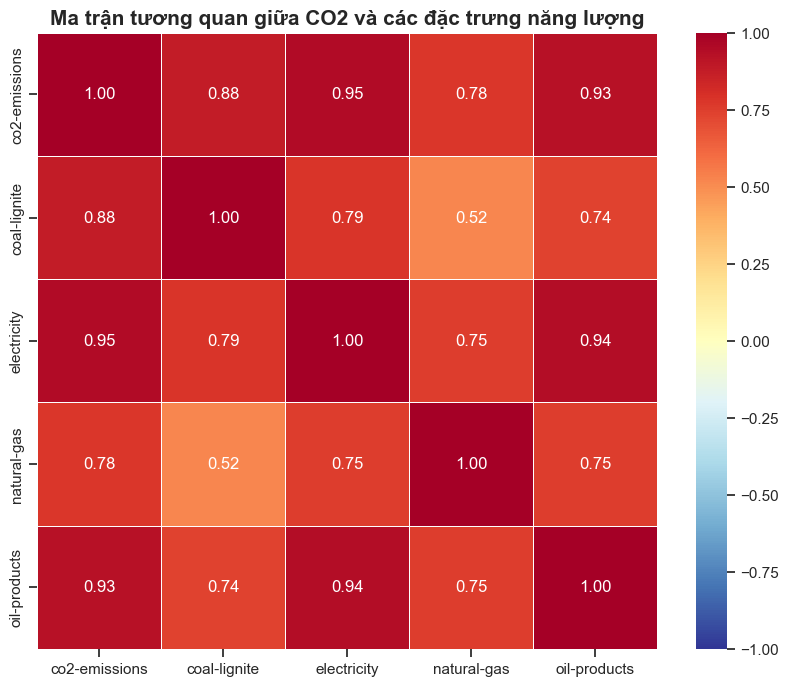

In [72]:
df = pd.read_csv('clean_data.csv')

num_cols = ['co2-emissions', 'coal-lignite', 'electricity', 
            'natural-gas', 'oil-products']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa CO2 và các đặc trưng năng lượng', fontsize=15, fontweight='bold')
plt.show()

- Nhận xét sơ đồ Correlation Map:

    + Các biến như coal-lignite, electricity, oil-products, natural-gas đều có mối tương quan tuyến tính thuận cực kỳ mạnh với biến mục tiêu Y (CO2-emission). Đây chính là những đặc trưng chính quan trọng cho mô hình học máy
    + Khi tự nhiên natural-gas thường sạch hơn với than đá nên sinh ra ít lượng carbon trên mỗi đơn vị cháy hơn so với than đá do đó hệ số tương quan với CO2 sẽ bị thấp hơn
    + Ngoài ra chúng ta có thể thấy, giữa electricity và oil-products hai loại năng lượng khác nhau có mức tương quan lớn 0.9 do đó giữa 2 biến đặc trưng này khả năng có những mối quan hệ tiềm ẩn như Quy mô kinh tế hoặc Tốc độ công nghiệp hóa đang tác động đồng thời lên cả hai nguồn năng lượng này.

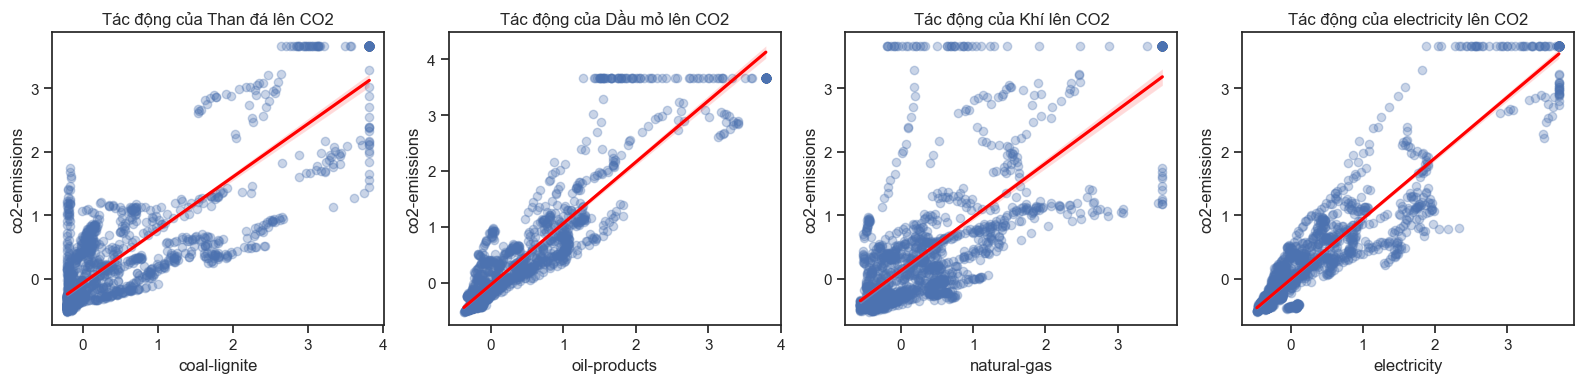

In [73]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.regplot(data=df, x='coal-lignite', y='co2-emissions', ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Tác động của Than đá lên CO2')

sns.regplot(data=df, x='oil-products', y='co2-emissions', ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title('Tác động của Dầu mỏ lên CO2')

sns.regplot(data=df, x='natural-gas', y='co2-emissions', ax=axes[2], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[2].set_title('Tác động của Khí lên CO2')

sns.regplot(data=df, x='electricity', y='co2-emissions', ax=axes[3], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[3].set_title('Tác động của electricity lên CO2')

plt.tight_layout()
plt.show()

- Các điểm dữ liệu bám rất sát với đường thẳng dốc lên đối với than,dầu, khí và điện.Tồn tại một mối quan hệ tuyến tính cực kỳ rõ ràng giữa việc đốt nhiên liệu này và lượng CO2 sinh ra
- Theo như biểu đồ, cả 4 đặc trưng đều thể hiện mối tương quan dương mạnh mẽ với lượng phát thải CO2.
- Các nhiên liệu như oil-products, electricity có độ phân tán hẹp nên nó càng quan trọng trong việc dự đoán biến mục tiêu Y

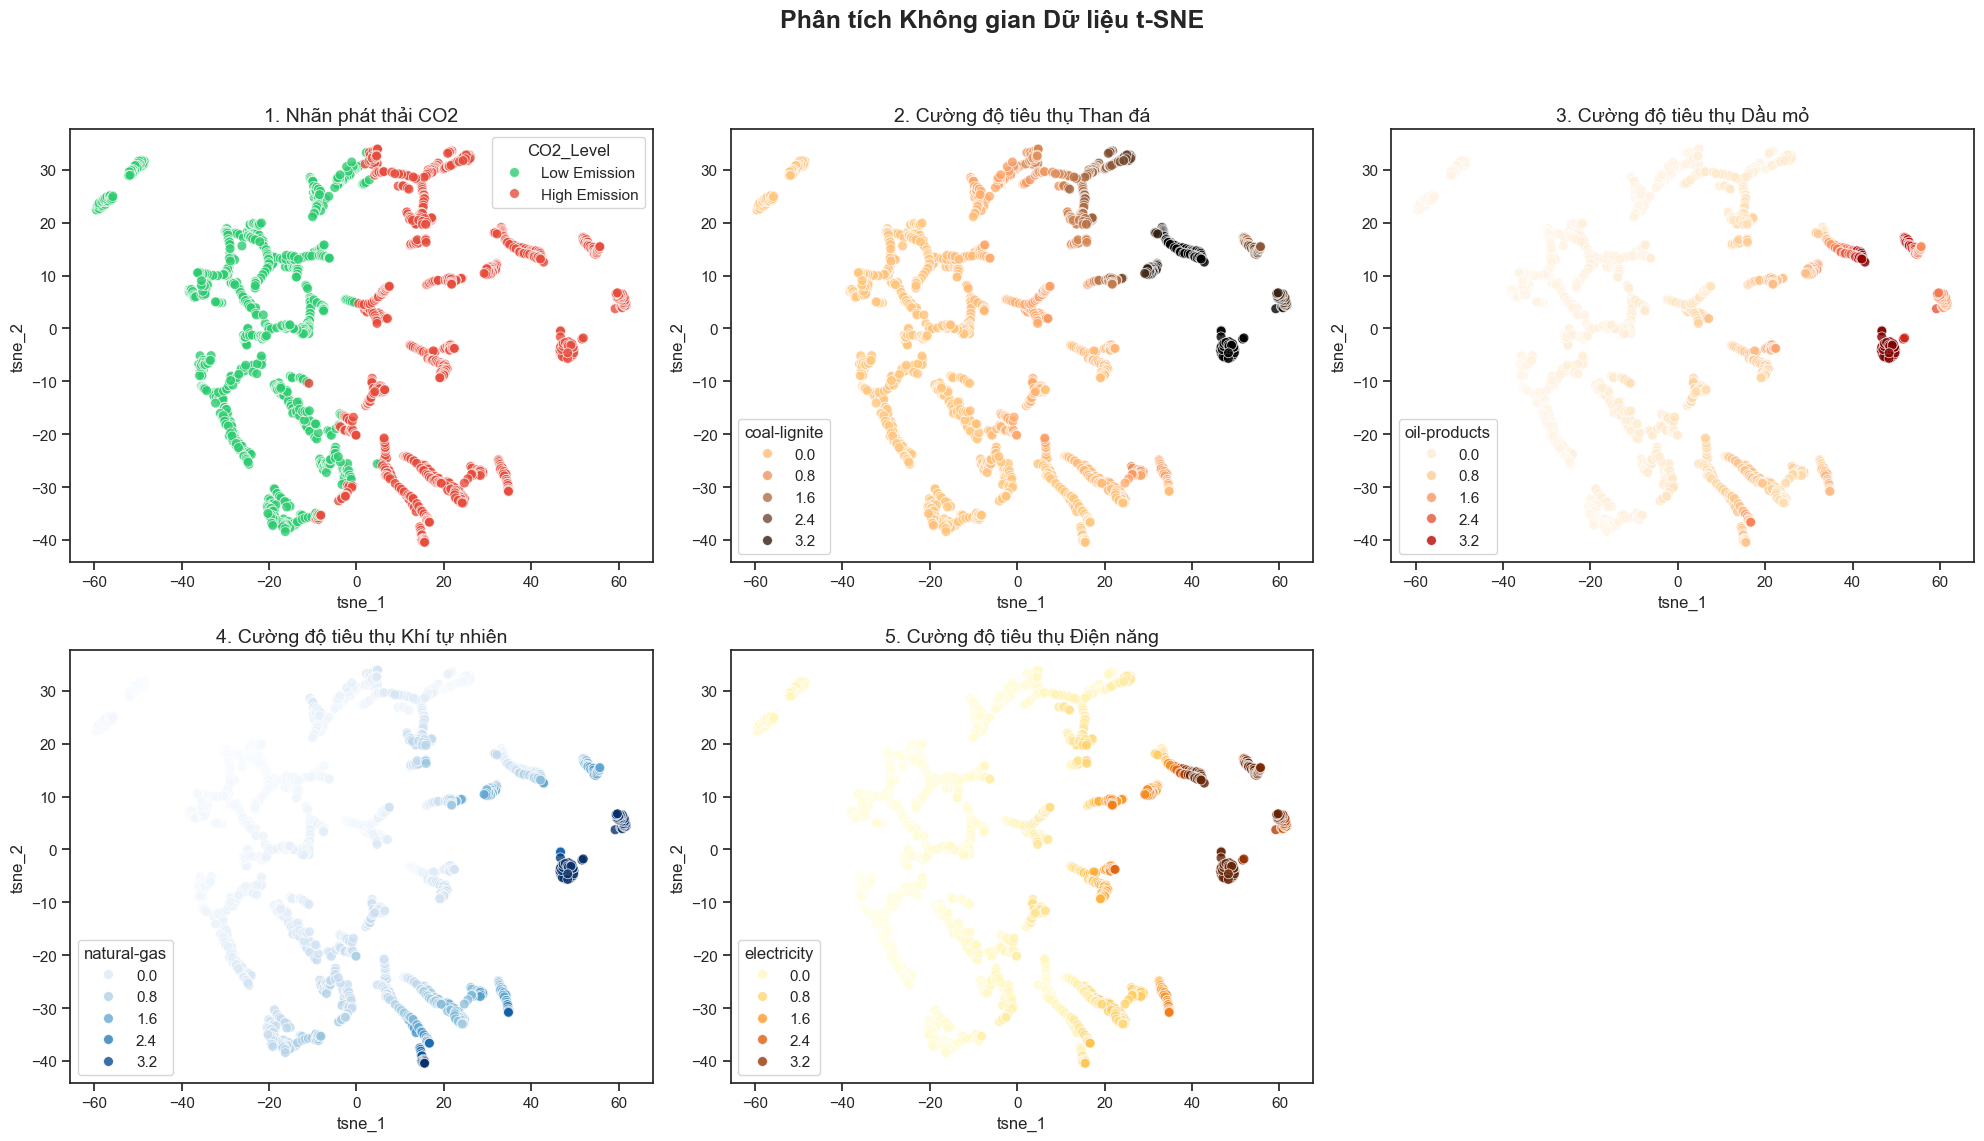

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

features = ['coal-lignite', 'natural-gas', 'oil-products', 'electricity']
X = df[features]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(X)

df['tsne_1'] = tsne_results[:, 0]
df['tsne_2'] = tsne_results[:, 1]

median_co2 = df['co2-emissions'].median()
df['CO2_Level'] = np.where(df['co2-emissions'] > median_co2, 'High Emission', 'Low Emission')

fig, axes = plt.subplots(2, 3, figsize=(20, 12)) 
fig.suptitle('Phân tích Không gian Dữ liệu t-SNE', fontsize=18, fontweight='bold')

sns.scatterplot(x='tsne_1', y='tsne_2', hue='CO2_Level', palette={'Low Emission': '#2ecc71', 'High Emission': '#e74c3c'}, 
                data=df, ax=axes[0, 0], s=50, alpha=0.8)
axes[0, 0].set_title('1. Nhãn phát thải CO2', fontsize=14)

sns.scatterplot(x='tsne_1', y='tsne_2', hue='coal-lignite', palette='copper_r', 
                data=df, ax=axes[0, 1], s=50, alpha=0.8)
axes[0, 1].set_title('2. Cường độ tiêu thụ Than đá', fontsize=14)

sns.scatterplot(x='tsne_1', y='tsne_2', hue='oil-products', palette='OrRd', 
                data=df, ax=axes[0, 2], s=50, alpha=0.8)
axes[0, 2].set_title('3. Cường độ tiêu thụ Dầu mỏ', fontsize=14)

sns.scatterplot(x='tsne_1', y='tsne_2', hue='natural-gas', palette='Blues', 
                data=df, ax=axes[1, 0], s=50, alpha=0.8)
axes[1, 0].set_title('4. Cường độ tiêu thụ Khí tự nhiên', fontsize=14)

sns.scatterplot(x='tsne_1', y='tsne_2', hue='electricity', palette='YlOrBr', 
                data=df, ax=axes[1, 1], s=50, alpha=0.8)
axes[1, 1].set_title('5. Cường độ tiêu thụ Điện năng', fontsize=14)

axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

- Ta có thể dễ dàng nhận ra tính chất cụm của lượng phát thải CO2

## 6. KẾT LUẬN

- Ta có thể dựa đoán 1 cách chính xác co2 emissions dựa trên 6 đặc trưng sau
    + country
    + year
    + oil products consumption
    + natural-gas consumption
    + coal-lignite consumption
    + electricity consumption


- Đối với biến renewables và renewables-wind-solar, mặc dù trên lý thuyết chúng có sự tương quan(nước càng dùng nhiều năng lượng tái tạo thì lượng co2 phát thải càng giảm) nhưng trên dữ liệu ta lại thấy rằng chúng chưa có mối quan hệ quá rõ ràng so với lượng co2 thải ra. 
Biến total-energy có sự tương quan tuyến tính mạnh với lượng co2 phát thải gần như bằng 1 nhưng khi đưa vào mô hình sẽ dễ làm cho mô hình chỉ tập trung học từ total-energy, vô tình bỏ qua những chi tiết quan trọng về cơ cấu năng lượng

## 7. TÀI LIỆU THAM KHẢO

- https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- https://www.datacamp.com/tutorial/introduction-t-sne
- https://www.datacamp.com/tutorial/random-forests-classifier-python?utm_aid=157156376311&utm_loc=9047170-&utm_mtd=-c&utm_kw=&gad_campaignid=19589720824